# Setup imports, constants, and default disk parameters
This cell imports required libraries and defines the base disk and stellar parameters used throughout the notebook.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G,k,m_p
from scipy.integrate import simpson

# Constants
AU = 1.495978707e11
MSUN = 1.98847e30
RSUN = 6.957e8
LSUN = 3.828e26
YEAR = 365.25*24*3600
MU = 2.3
MH = m_p
PI = np.pi

# Matplotlib settings
plt.rcParams['figure.figsize']=(7,5)
plt.rcParams['font.size']=12
plt.rcParams['axes.grid']=True
plt.rcParams['image.cmap']='inferno'

# Default parameters
def default_parameters():

    return {
        'MSTAR':0.75,
        'RSTAR':1.0888,
        'LSTAR':0.242,
        'TEFF':4000.0,

        'RIN':4.5784,
        'ROUT':192.95,
        'RC':48.0,
        'GAMMA':1.5181,

        'MDISK':0.0448,
        "ALPHA":1e-3,

        'T0':214,
        'R0':1.0,
        'Q':(3.0-2.0*1.2121),

        'NR':500,
        'NZ':300
    }

# DiskModel definition
Defines the DiskModel class and its compute() method for building the radial and vertical structure of a protoplanetary disk.


In [8]:
class DiskModel:

    def __init__(self,pars):

        self.pars=pars

        for k,v in pars.items():
            setattr(self,k,v)

    def compute(self):

        # SI units
        self.RIN_SI = self.RIN*AU
        self.ROUT_SI = self.ROUT*AU
        self.RC_SI = self.RC*AU
        self.MDISK_SI = self.MDISK*MSUN
        self.MSTAR_SI = self.MSTAR*MSUN

        # radial grid
        self.R = np.logspace( np.log10(self.RIN_SI), np.log10(self.ROUT_SI),self.NR)
        self.R_AU = self.R/AU

        # temperature profile
        self.T = np.maximum( (self.T0 * (self.LSTAR)**0.25) * ( self.R/(self.R0*AU) ) ** (-self.Q), 0 )

        # surface density
        def sigma_shape(R):
            x = R / self.RC_SI
            return x**( -self.GAMMA ) * np.exp( -(x)**(2-self.GAMMA) )

        Rint = np.logspace( np.log10(self.RIN_SI), np.log10(self.ROUT_SI), 1000 )
        integrand = sigma_shape(Rint) * Rint
        I=simpson( integrand, x=Rint )

        self.sigma_c = self.MDISK_SI / (2*PI*I)
        self.sigma = self.sigma_c * sigma_shape(self.R)

        # dynamics
        self.omega = np.sqrt( ( G * self.MSTAR_SI ) / self.R**3 )
        self.vkep = np.sqrt( ( G * self.MSTAR_SI ) / self.R )
        self.cs = np.sqrt( ( k * self.T ) / (MU * MH) )

        self.H = self.cs / self.omega
        self.H_AU = self.H / AU
        self.aspect_ratio = self.H / self.R

        # Kinematic viscosity (m²/s)
        self.nu = self.ALPHA * self.cs * self.H

        # Radial gas velocity (negative = inward)
        self.vr = -(3 * self.nu) / (2 * self.R)
        
        # Mass accretion rate (kg/s)
        self.mdot = -2 * PI * self.R * self.sigma * self.vr

        # Convert to solar masses per year
        SEC_PER_YEAR = 365.25 * 24 * 3600
        self.mdot_msunyr = self.mdot * SEC_PER_YEAR / MSUN

        # Viscous timescale
        self.tvisc = self.R**2 / self.nu
        self.tvisc_year = self.tvisc / SEC_PER_YEAR

        # vertical grid
        eta=np.linspace(-5,5,self.NZ)
        self.ZZ=self.H[:,None]*eta[None,:]
        self.ZZ_AU=self.ZZ/AU
        self.RR=np.repeat(self.R[:,None],self.NZ,axis=1)
        self.RR_AU=self.RR/AU

        self.update_from_sigma()

    def update_from_sigma(self):
            
        sigma2 = self.sigma[:, None]
        H2 = self.H[:, None]

        self.rho = ( sigma2 / (np.sqrt(2 * PI) * H2)) * np.exp(-0.5 * (self.ZZ / H2) ** 2)
        mid = self.NZ // 2
        self.rho_mid = self.rho[:, mid]

        self.Pmid = self.rho_mid * self.cs**2
        self.dPdr = np.gradient(self.Pmid, self.R)

        self.LOGRHO = np.log10(self.rho)
        self.toomre_Q = self.cs * self.omega / (PI * G * self.sigma)

        self.mdot = -2 * PI * self.R * self.sigma * self.vr
        SEC_PER_YEAR = 365.25 * 24 * 3600
        self.mdot_msunyr = self.mdot * SEC_PER_YEAR / MSUN
        
        # convenience
        self.ZR=self.ZZ_AU[:,mid:]/self.RR_AU[:,mid:]

    def describe(self):

        s=""
        s+="DiskModel Summary\n"
        s+="-"*40+"\n\n"

        s+="Star\n"
        s+="-----\n"
        s+=f"Mass        : {self.MSTAR:.3f} Msun\n"
        s+=f"Radius      : {self.RSTAR:.3f} Rsun\n"
        s+=f"Luminosity  : {self.LSTAR:.3f} Lsun\n"
        s+=f"Teff        : {self.TEFF:.0f} K\n\n"

        s+="Disk\n"
        s+="-----\n"
        s+=f"Mass        : {self.MDISK:.4f} Msun\n"
        s+=f"Rin         : {self.RIN:.2f} AU\n"
        s+=f"Rout        : {self.ROUT:.2f} AU\n"
        s+=f"Rc          : {self.RC:.2f} AU\n"
        s+=f"Gamma       : {self.GAMMA:.3f}\n\n"

        s+="Temperature\n"
        s+="-----------\n"
        s+=f"Min         : {self.T.min():.2f} K\n"
        s+=f"Max         : {self.T.max():.2f} K\n\n"

        s+="Hydrostatic\n"
        s+="-----------\n"
        s+=f"H/R min     : {self.aspect_ratio.min():.4f}\n"
        s+=f"H/R max     : {self.aspect_ratio.max():.4f}\n\n"

        s+="Density\n"
        s+="-------\n"
        s+=f"rho min     : {self.rho.min():.3e}\n"
        s+=f"rho max     : {self.rho.max():.3e}\n\n"

        s+="Grid\n"
        s+="----\n"
        s+=f"Nr          : {self.NR}\n"
        s+=f"Nz          : {self.NZ}\n"
        s+=f"Shape       : {self.rho.shape}\n\n"

        s+="Viscosity\n"
        s+="---------\n"
        s+=f"alpha              : {self.ALPHA:.1e}\n"
        s+=f"v(Rin)             : {self.nu[0]:.3e} m²/s\n"
        s+=f"v(Rout)            : {self.nu[-1]:.3e} m²/s\n"

        s+=f"Ṁ(Rin)             : {self.mdot_msunyr[0]:.3e} Msun/yr\n"
        s+=f"Ṁ(Rout)            : {self.mdot_msunyr[-1]:.3e} Msun/yr\n"

        s+=f"Viscous time Rin   : {self.tvisc_year[0]:.3e} yr\n"
        s+=f"Viscous time Rout  : {self.tvisc_year[-1]:.3e} yr\n"


        return s

# Initialize and compute the disk model
Constructs a disk model from the default parameters, computes its structure, and prints a summary of the results.


In [9]:
pars = default_parameters()

disk = DiskModel(pars)

disk.compute()

print(disk.describe())

DiskModel Summary
----------------------------------------

Star
-----
Mass        : 0.750 Msun
Radius      : 1.089 Rsun
Luminosity  : 0.242 Lsun
Teff        : 4000 K

Disk
-----
Mass        : 0.0448 Msun
Rin         : 4.58 AU
Rout        : 192.95 AU
Rc          : 48.00 AU
Gamma       : 1.518

Temperature
-----------
Min         : 7.25 K
Max         : 62.51 K

Hydrostatic
-----------
H/R min     : 0.0393
H/R max     : 0.0869

Density
-------
rho min     : 2.308e-18
rho max     : 8.647e-08

Grid
----
Nr          : 500
Nz          : 300
Shape       : (500, 300)

Viscosity
---------
alpha              : 1.0e-03
v(Rin)             : 1.275e+10 m²/s
v(Rout)            : 4.045e+11 m²/s
Ṁ(Rin)             : 1.112e-08 Msun/yr
Ṁ(Rout)            : 2.355e-10 Msun/yr
Viscous time Rin   : 1.166e+06 yr
Viscous time Rout  : 6.527e+07 yr



# DiskVisualizer class
Defines plotting utilities to visualize surface density, temperature, scale height, aspect ratio, density structure, and dynamics.


In [12]:
class DiskVisualizer:

    @staticmethod
    def plot_sigma(disk):

        fig,ax=plt.subplots(figsize=(8,5))

        ax.plot(disk.R_AU,disk.sigma,lw=2)

        ax.set_xlabel("Radius [AU]")
        ax.set_ylabel(r"$\Sigma$ [kg m$^{-2}$]")
        ax.set_title("Surface Density")

        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_temperature(disk):

        fig,ax=plt.subplots(figsize=(8,5))

        ax.plot(disk.R_AU,disk.T,lw=2)

        ax.set_xlabel("Radius [AU]")
        ax.set_ylabel("Temperature [K]")
        ax.set_title("Temperature Profile")

        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_scale_height(disk):

        fig,ax=plt.subplots(figsize=(8,5))

        ax.plot(disk.R_AU,disk.H_AU,lw=2)

        ax.set_xlabel("Radius [AU]")
        ax.set_ylabel("H [AU]")
        ax.set_title("Scale Height")

        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_aspect_ratio(disk):

        fig,ax=plt.subplots(figsize=(8,5))

        ax.plot(disk.R_AU,disk.aspect_ratio,lw=2)

        ax.set_xlabel("Radius [AU]")
        ax.set_ylabel("H/R")
        ax.set_title("Disk Flaring")

        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_density(disk):

        mid=disk.NZ//2

        vmin=np.floor(disk.LOGRHO.min())
        vmax=np.ceil(disk.LOGRHO.max())

        contour_levels=np.arange(vmin,vmax+1,1)

        fig,ax=plt.subplots(figsize=(11,6))

        cf=ax.contourf(
            disk.RR_AU[:,mid:],
            disk.ZR,
            disk.LOGRHO[:,mid:],
            levels=100,
            cmap='turbo'
        )

        ax.contour(
            disk.RR_AU[:,mid:],
            disk.ZR,
            disk.LOGRHO[:,mid:],
            levels=contour_levels,
            colors='k',
            linewidths=0.5
        )

        ax.grid(False)

        plt.colorbar(
            cf,
            label=r'$\log_{10}(\rho)$ [kg m$^{-3}$]'
        )

        ax.set_xscale('log')

        ax.set_xlabel('Radius [AU]')
        ax.set_ylabel('z/r')

        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_dynamics(disk):

        fig,ax=plt.subplots(1,2,figsize=(12,5))

        ax[0].plot(
            disk.R_AU,
            disk.vkep/1000,
            lw=2
        )

        ax[0].set_xlabel("Radius [AU]")
        ax[0].set_ylabel("Velocity [km/s]")
        ax[0].set_title("Keplerian Velocity")

        ax[1].plot(
            disk.R_AU,
            disk.omega,
            lw=2
        )

        ax[1].set_xscale('log')

        ax[1].set_xlabel("Radius [AU]")
        ax[1].set_ylabel(r'$\Omega$ [rad s$^{-1}$]')
        ax[1].set_title("Angular Frequency")

        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_vertical_profiles(disk,radii=[10,50,100]):

        fig,ax=plt.subplots(figsize=(8,6))

        for r0 in radii:

            idx=np.argmin(
                np.abs(disk.R_AU-r0)
            )

            ax.plot(
                disk.ZZ_AU[idx],
                np.log10(disk.rho[idx]),
                label=f'{disk.R_AU[idx]:.0f} AU'
            )

        ax.set_xlabel("Height [AU]")

        ax.set_ylabel(
            r'$\log_{10}(\rho)$ [kg m$^{-3}$]'
        )

        ax.legend()

        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_pressure(disk):

        fig,ax=plt.subplots(1,2,figsize=(12,5))

        ax[0].plot(
            disk.R_AU,
            disk.Pmid
        )

        ax[0].set_xscale('log')

        ax[0].set_xlabel('Radius [AU]')
        ax[0].set_ylabel('Pressure [Pa]')
        ax[0].set_title('Midplane Pressure')

        ax[1].plot(
            disk.R_AU,
            disk.dPdr
        )

        ax[1].set_xscale('log')

        ax[1].set_xlabel('Radius [AU]')
        ax[1].set_ylabel(r'$\partial P/\partial R$')
        ax[1].set_title('Pressure Gradient')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_toomre_Q(disk):

        fig,ax=plt.subplots(figsize=(8,5))

        ax.plot(
            disk.R_AU,
            disk.toomre_Q,
            lw=2,
            label='Toomre Q'
        )

        ax.axhline(
            1,
            ls='--',
            color='r',
            label='Q=1'
        )

        ax.axhline(
            2,
            ls=':',
            color='k',
            label='Q=2'
        )

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Radius [AU]')
        ax.set_ylabel('Q')

        ax.set_title('Toomre Stability Parameter')

        ax.grid(True)

        ax.legend()

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_viscosity(disk):
        plt.figure(figsize=(7,5))

        plt.plot(disk.R_AU,
                disk.nu)

        plt.xlabel("Radius (AU)")
        plt.ylabel(r"$\nu$ (m$^2$/s)")
        plt.title("Kinematic Viscosity")

        plt.grid(True,which="both")
        plt.show()

    @staticmethod
    def plot_accretion_rate(disk):
        plt.figure(figsize=(7,5))

        plt.plot(disk.R_AU,
                    disk.mdot_msunyr)

        plt.xlabel("Radius (AU)")
        plt.ylabel(r"$\dot{M}$ (M$_\odot$/yr)")
        plt.title("Mass Accretion Rate")

        plt.grid(True)
        plt.show()

    @staticmethod
    def plot_radial_velocity(disk):
        plt.figure(figsize=(7,5))

        plt.plot(disk.R_AU,
                    disk.vr)

        plt.xlabel("Radius (AU)")
        plt.ylabel("Radial Velocity (m/s)")
        plt.title("Gas Inflow Velocity")

        plt.grid(True)
        plt.show()

    @staticmethod
    def plot_viscous_timescale(disk):
        plt.figure(figsize=(7,5))

        plt.plot(disk.R_AU,
                disk.tvisc_year)

        plt.xlabel("Radius (AU)")
        plt.ylabel("Years")
        plt.title("Viscous Timescale")

        plt.grid(True,which="both")
        plt.show()

    @staticmethod
    def plot_all(disk):

        DiskVisualizer.plot_sigma(disk)

        DiskVisualizer.plot_temperature(disk)

        DiskVisualizer.plot_scale_height(disk)

        DiskVisualizer.plot_aspect_ratio(disk)

        DiskVisualizer.plot_dynamics(disk)
        
        DiskVisualizer.plot_density(disk)
        
        DiskVisualizer.plot_vertical_profiles(disk)

        DiskVisualizer.plot_pressure(disk)

        DiskVisualizer.plot_toomre_Q(disk)

        DiskVisualizer.plot_viscosity(disk)

        DiskVisualizer.plot_accretion_rate(disk)

        DiskVisualizer.plot_radial_velocity(disk)

        DiskVisualizer.plot_viscous_timescale(disk)

# Plot all disk diagnostics
Runs the full suite of DiskVisualizer plots for the computed disk model.


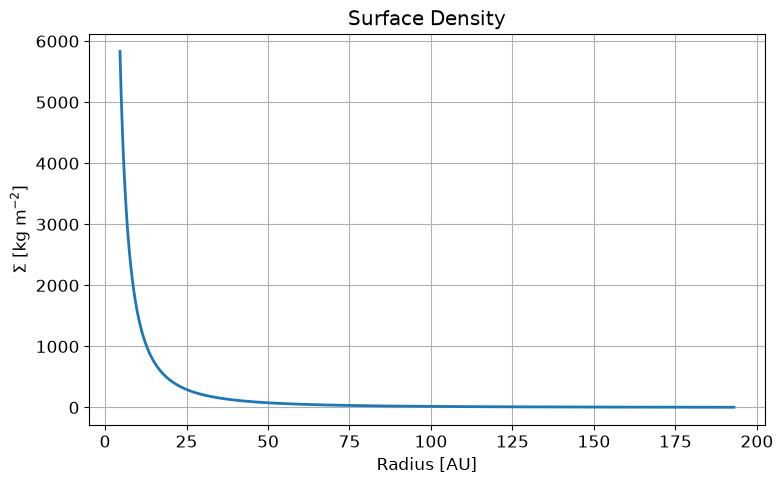

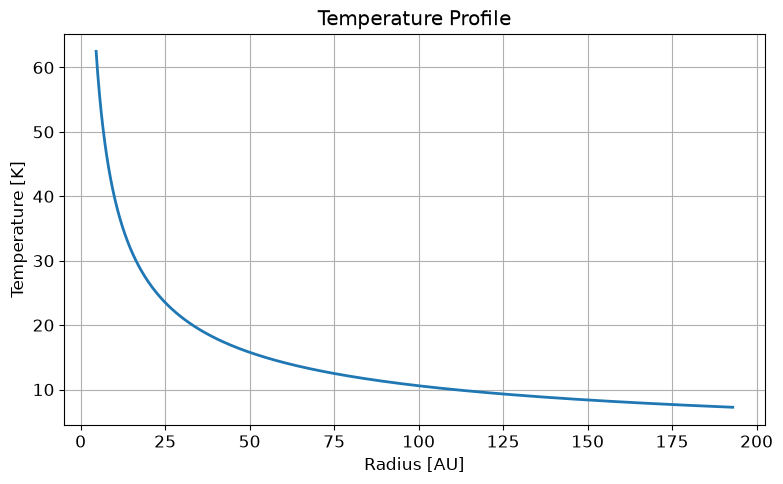

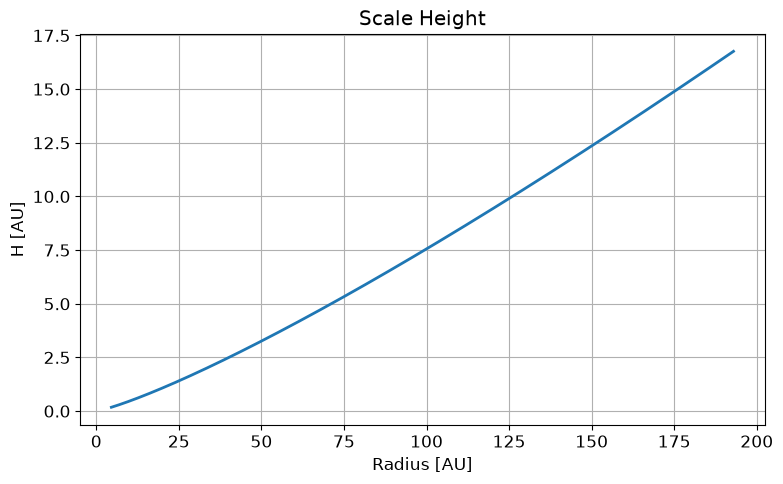

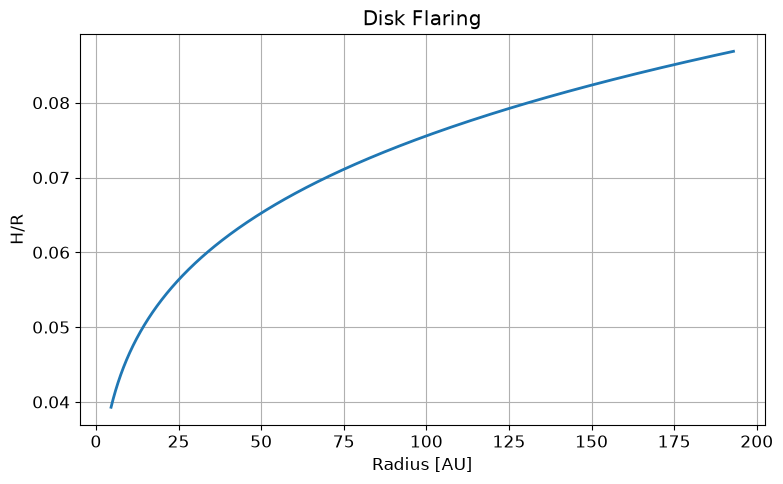

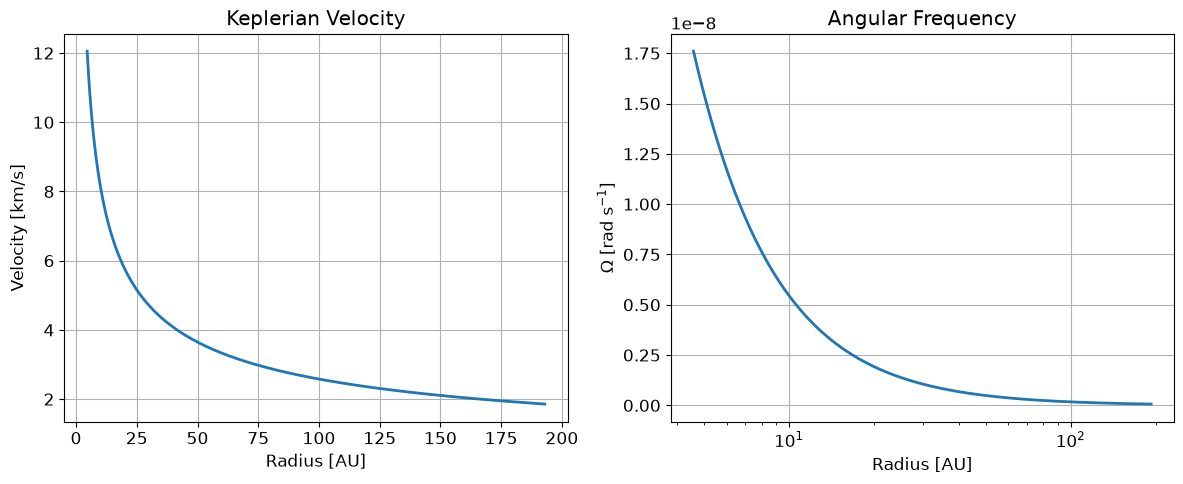

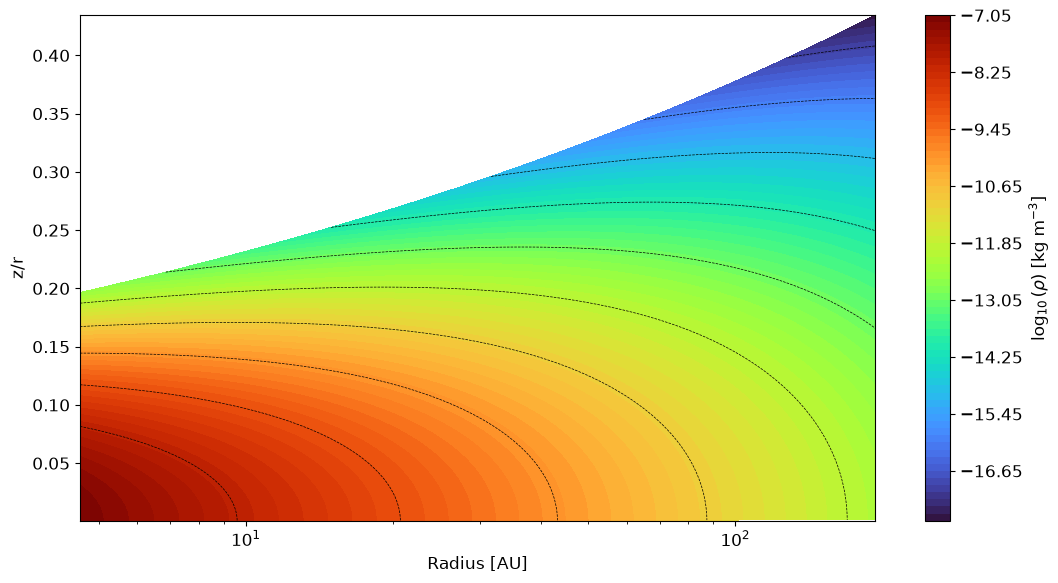

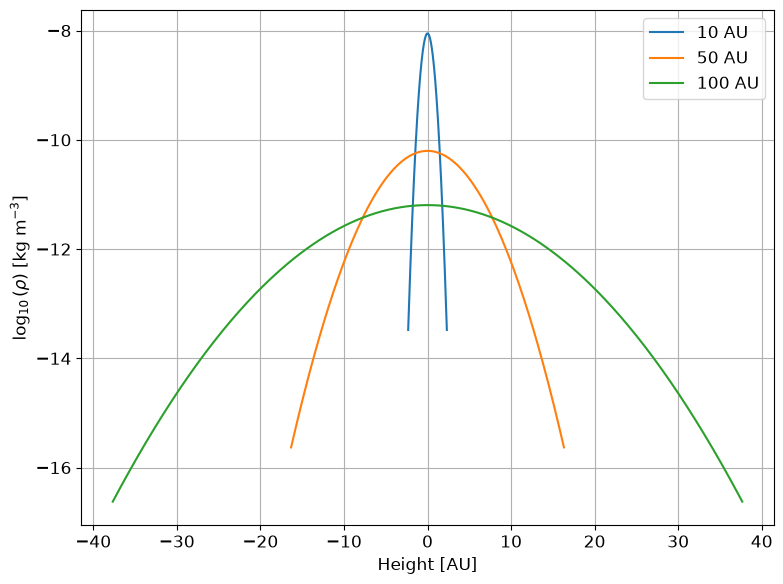

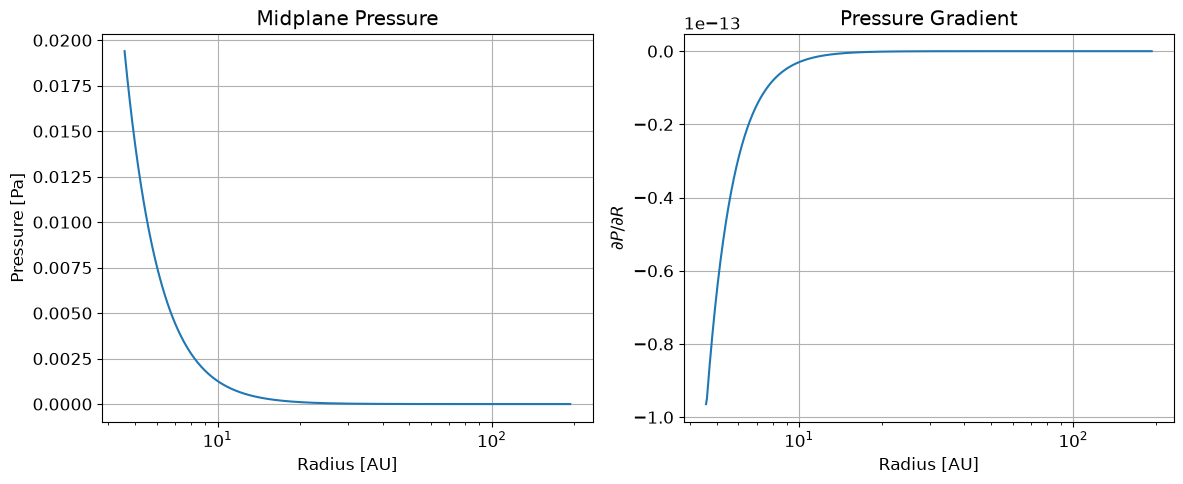

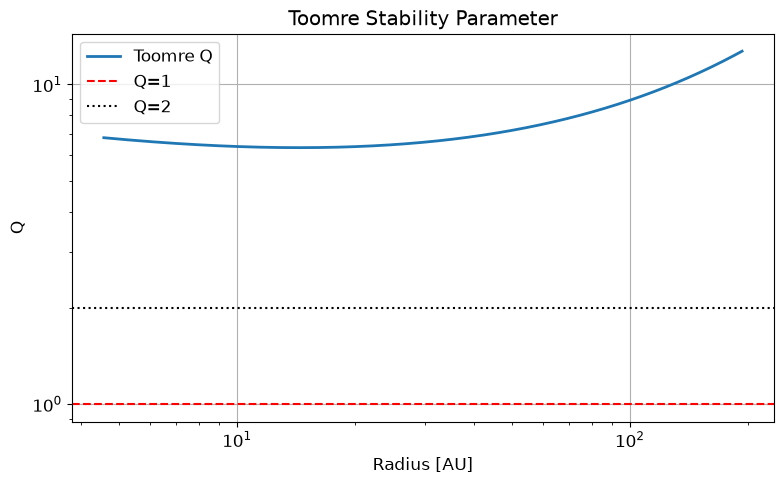

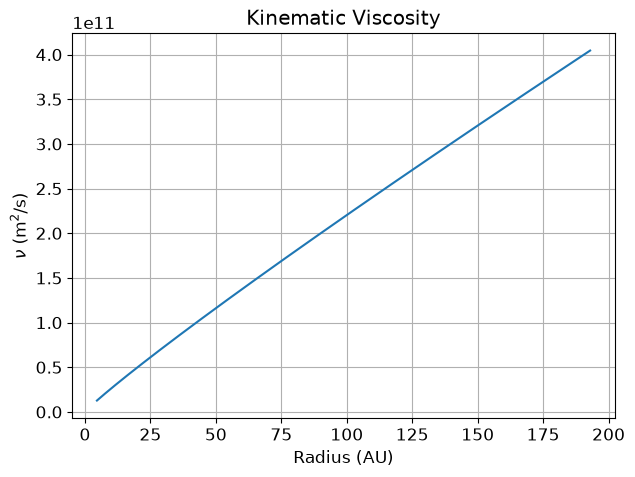

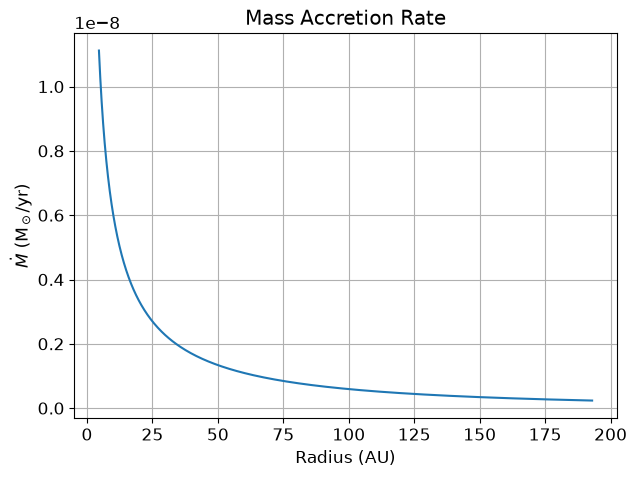

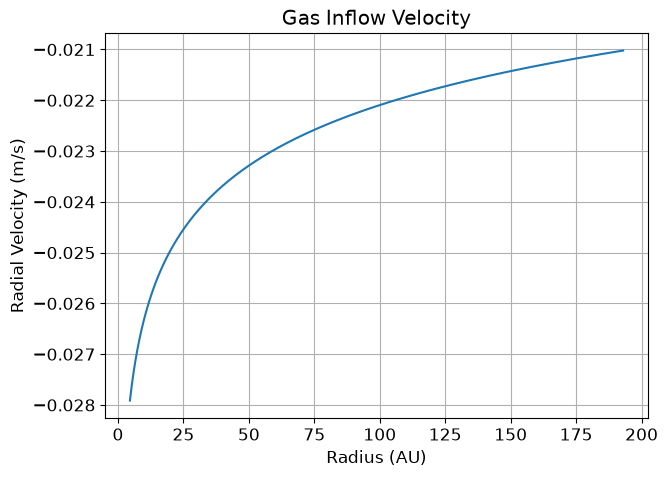

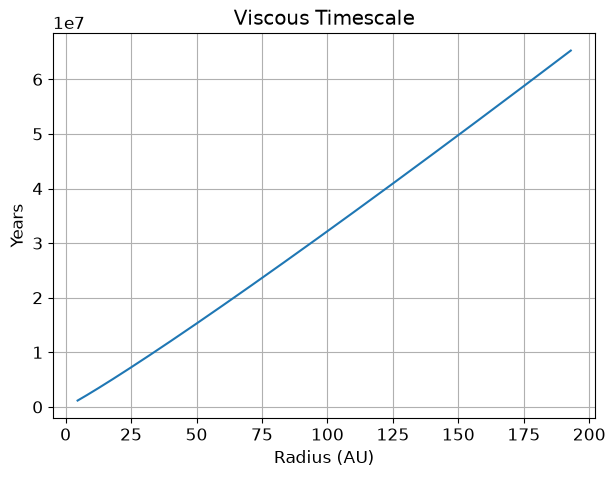

In [13]:
DiskVisualizer.plot_all(disk)

# Adding Planetary Gap

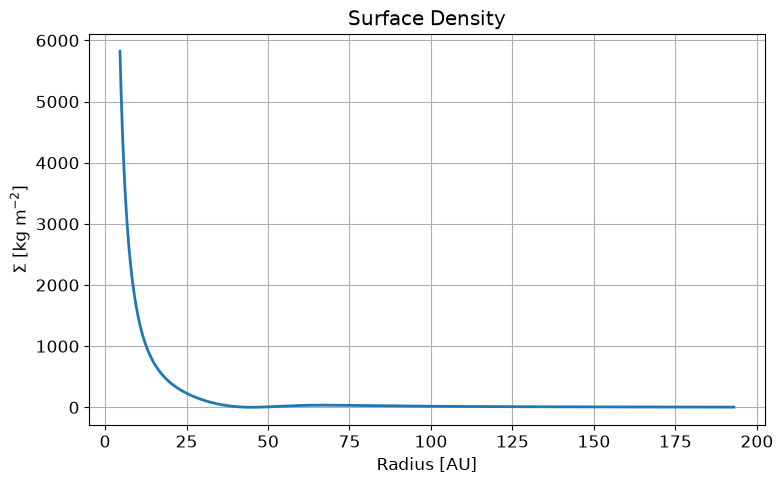

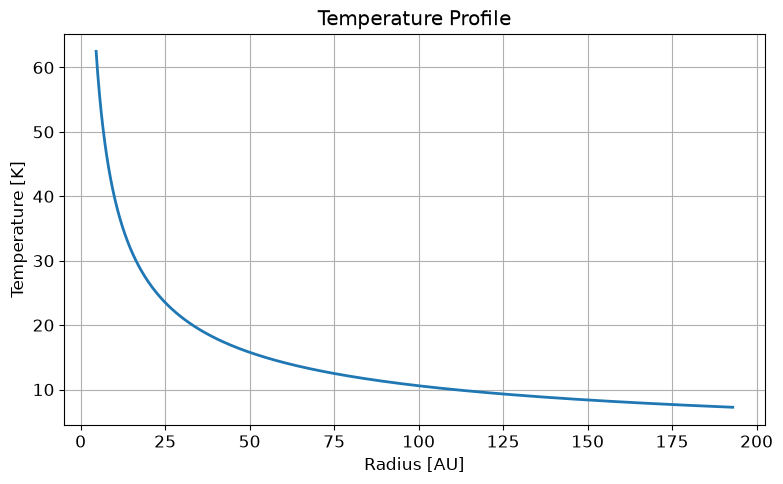

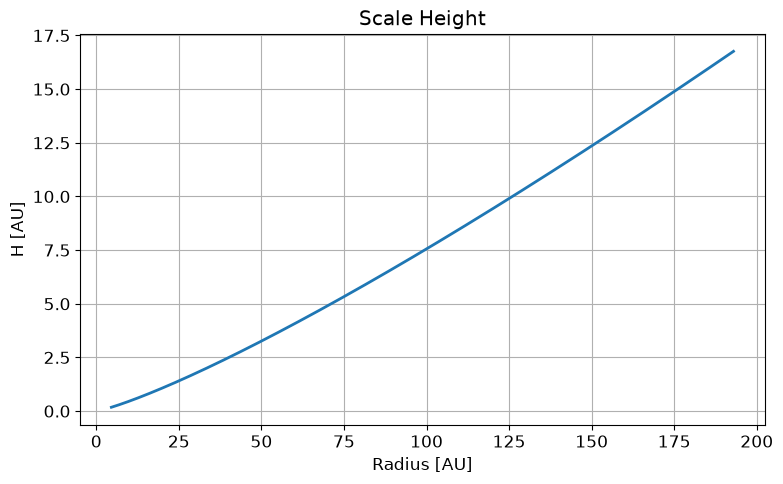

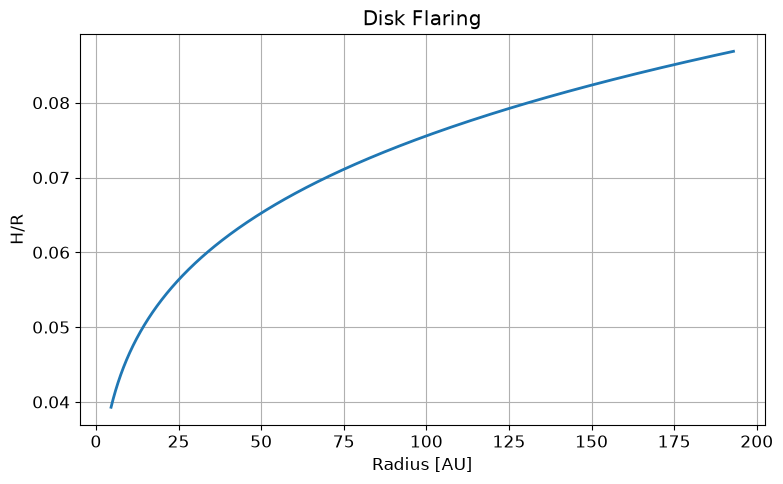

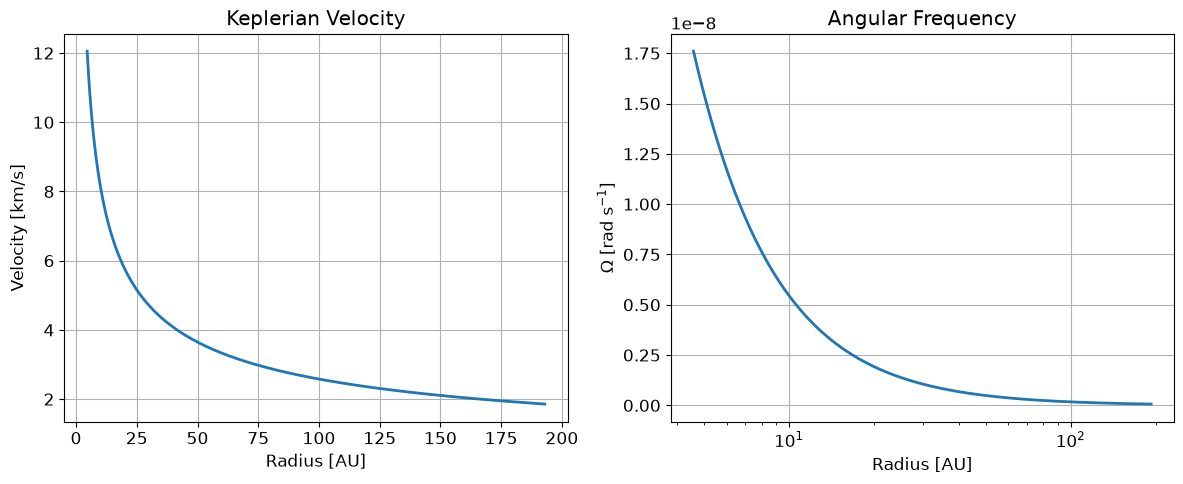

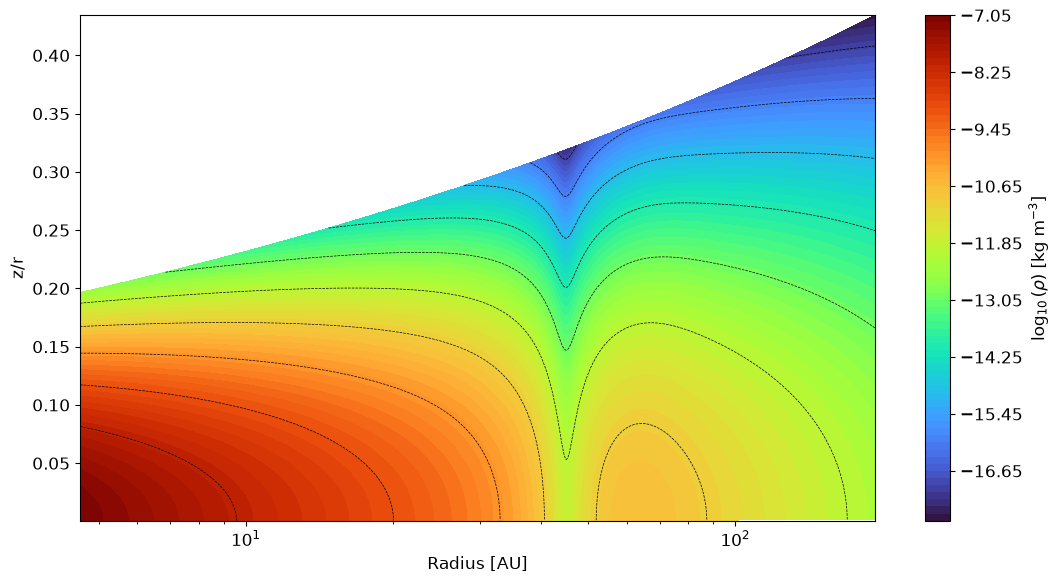

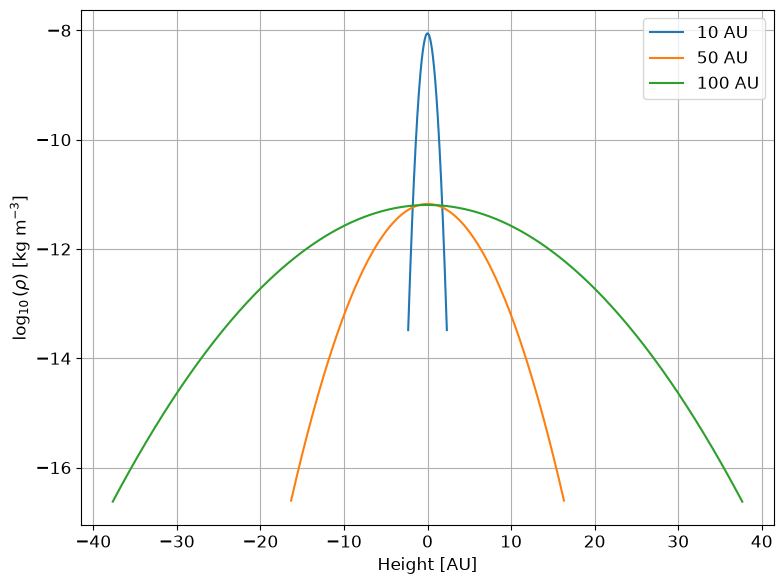

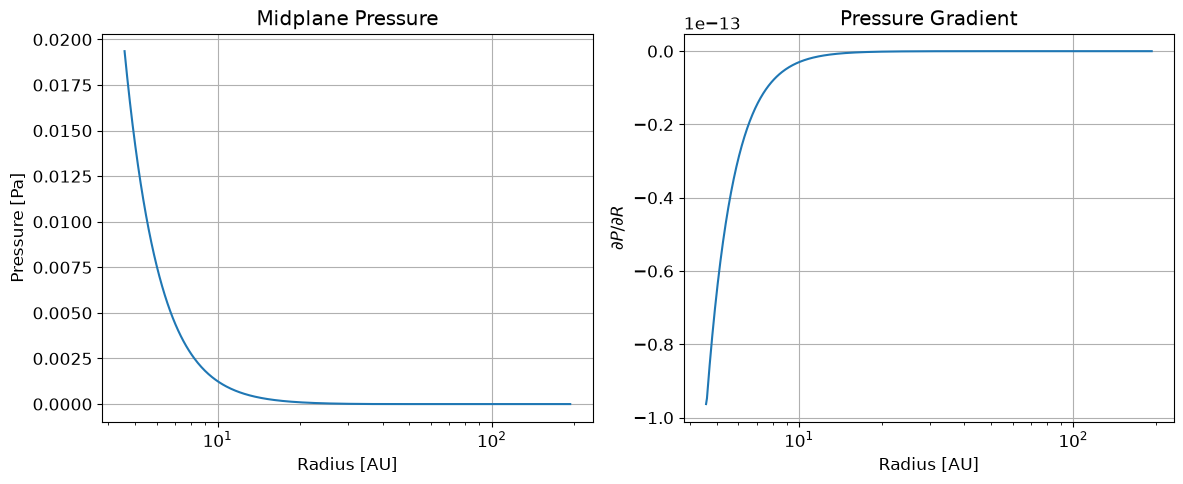

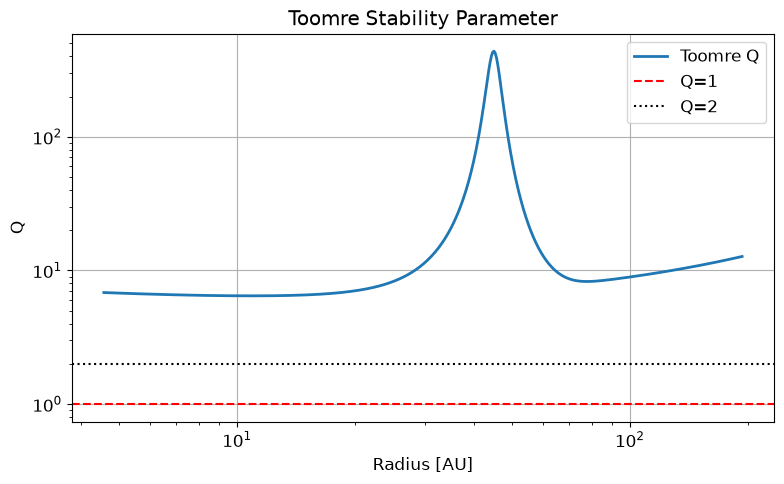

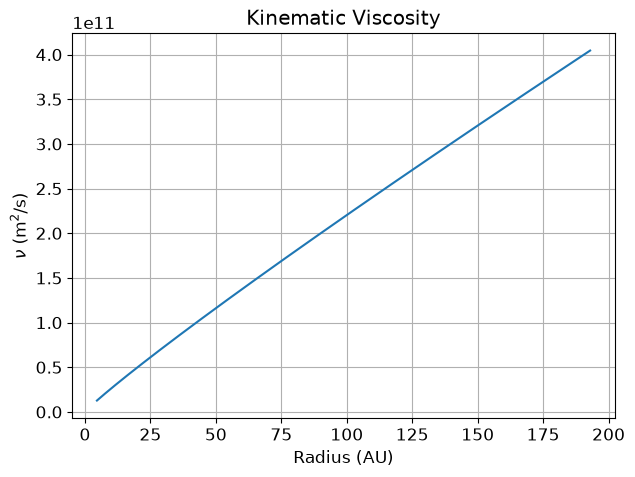

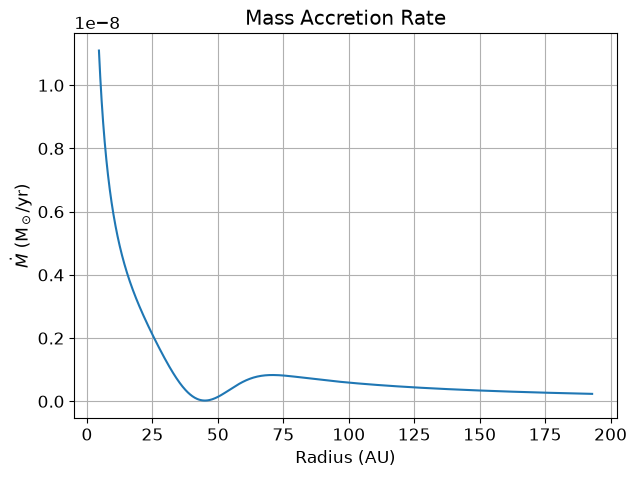

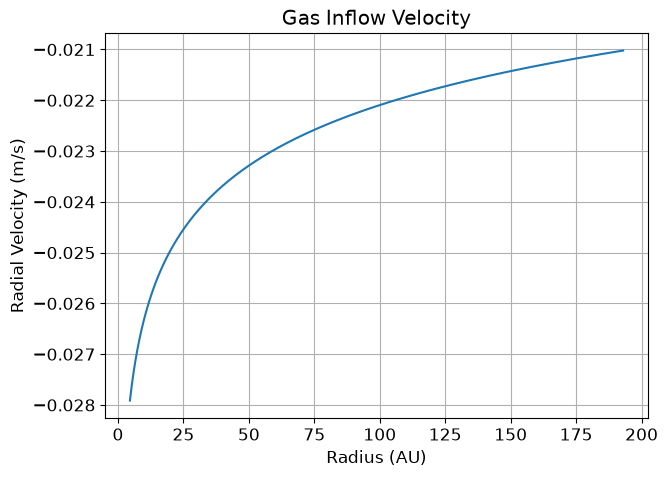

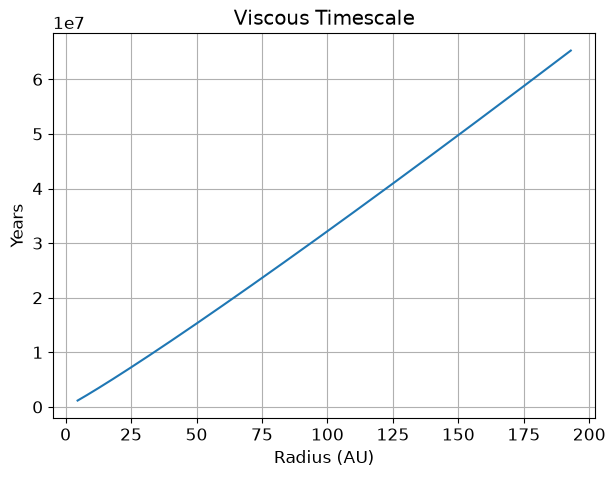

In [14]:
import copy

def add_planet(disk,mass,radius,width=None,inplace=False):
    
    if not inplace:
        disk = copy.deepcopy(disk)

    if not hasattr(disk, "planets"):
        disk.planets = []

    disk.planets.append({"mass": mass,"radius": radius})

    MJUP = 1.898e27

    Mp = mass * MJUP
    Rp = radius * AU

    idx = np.argmin(np.abs(disk.R - Rp))
    h = disk.aspect_ratio[idx]
    q = Mp / disk.MSTAR_SI
    alpha = disk.ALPHA

    K = q**2 / (alpha * h**5)
    delta = 1 / (1 + 0.04 * K)

    if width is None:
        width = 4*disk.H[idx]/AU

    width_si = width * AU

    profile = 1 - (1 - delta) * np.exp(-0.5 * ((disk.R - Rp) / width_si) ** 2)

    disk.sigma *= profile
    disk.gap_profile = profile
    disk.gap_depth = delta
    disk.gap_width = width

    disk.update_from_sigma()

    return disk

gap_disk = add_planet(disk,mass=1,radius=45)
DiskVisualizer.plot_all(gap_disk)

# DiskComparisonVisualizer class
Defines utilities for comparing multiple disk models side-by-side across different physical quantities.


In [15]:
class DiskComparisonVisualizer:

    @staticmethod
    def _plot(models, labels, xattr, yattr, xlabel, ylabel, title, logx=False, logy=False):
        fig, ax = plt.subplots(figsize=(8,5))
        for d, lab in zip(models, labels):
            ax.plot(getattr(d, xattr), getattr(d, yattr), lw=2, label=lab)
        if logx:
            ax.set_xscale('log')
        if logy:
            ax.set_yscale('log')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def compare_sigma(models, labels):
        DiskComparisonVisualizer._plot(models, labels, 'R_AU', 'sigma',
                                       'Radius [AU]', r'$\Sigma$ [kg m$^{-2}$]',
                                       'Surface Density', logx=True, logy=True)

    @staticmethod
    def compare_kepvelocity(models, labels):
        DiskComparisonVisualizer._plot(models, labels, 'R_AU', 'vkep',
                                       'Radius [AU]', 'Keplerian Velocity [m/s]',
                                       'Keplerian Velocity', logx=True)

    @staticmethod
    def compare_temperature(models, labels):
        DiskComparisonVisualizer._plot(models, labels, 'R_AU', 'T',
                                       'Radius [AU]', 'Temperature [K]',
                                       'Temperature Profile', logx=True)

    @staticmethod
    def compare_scale_height(models, labels):
        DiskComparisonVisualizer._plot(models, labels, 'R_AU', 'H_AU',
                                       'Radius [AU]', 'H [AU]',
                                       'Scale Height', logx=True)

    @staticmethod
    def compare_aspect_ratio(models, labels):
        DiskComparisonVisualizer._plot(models, labels, 'R_AU', 'aspect_ratio',
                                       'Radius [AU]', 'H/R',
                                       'Disk Flaring', logx=True)

    @staticmethod
    def compare_midplane_density(models, labels):
        fig, ax = plt.subplots(figsize=(8,5))
        for d, lab in zip(models, labels):
            ax.plot(d.R_AU, d.rho_mid, lw=2, label=lab)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Radius [AU]')
        ax.set_ylabel(r'$\rho_{mid}$ [kg m$^{-3}$]')
        ax.set_title('Midplane Density')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def compare_density_maps(models, labels):

        n = len(models)

        fig, axs = plt.subplots(
            1,
            n,
            figsize=(5*n,5),
            sharex=True,
            sharey=True
        )

        if n == 1:
            axs = [axs]

        vmin = min(d.LOGRHO.min() for d in models)
        vmax = max(d.LOGRHO.max() for d in models)

        contour_levels = np.linspace(
            vmin,
            vmax,
            12
        )

        for i,(disk,label) in enumerate(zip(models,labels)):
            ax = axs[i]
            mid = disk.NZ//2

            cf = ax.contourf(
                disk.RR_AU[:,mid:],
                disk.ZR,
                disk.LOGRHO[:,mid:],
                levels=100,
                cmap='turbo',
                vmin=vmin,
                vmax=vmax
            )
            ax.contour(
                disk.RR_AU[:,mid:],
                disk.ZR,
                disk.LOGRHO[:,mid:],
                levels=contour_levels,
                colors='white',
                linewidths=0.4
            )
            ax.set_xscale('log')
            ax.minorticks_on()
            ax.text(
                0.97,
                0.97,
                label,
                transform=ax.transAxes,
                ha='right',
                va='top',
                fontsize=11,
                bbox=dict(
                    facecolor='white',
                    alpha=0.8,
                    edgecolor='none'
                )
            )

            ax.set_xlabel( 'Radius [AU]' )

            if i == 0:
                ax.set_ylabel( 'z/r' )
            else:
                ax.set_yticklabels([])

        plt.subplots_adjust( wspace=0.03 )

        cbar = fig.colorbar(
            cf,
            ax=axs,
            shrink=0.9,
            pad=0.02
        )
        
        cbar.set_label( r'$\log_{10}(\rho)$ [kg m$^{-3}$]' )
        plt.show()


    @staticmethod
    def compare_toomre_Q(models, labels):
        fig, ax = plt.subplots(figsize=(8,5))
        for d, lab in zip(models, labels):
            ax.plot(d.R_AU, d.toomre_Q, lw=2, label=lab)
        ax.axhline(1, ls='--', color='red')
        ax.axhline(2, ls=':', color='black')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Radius [AU]')
        ax.set_ylabel('Q')
        ax.set_title('Toomre Stability')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def compare_vertical_profiles(models, labels, radius=100):
        fig, ax = plt.subplots(figsize=(8,6))
        for d, lab in zip(models, labels):
            idx = np.argmin(np.abs(d.R_AU - radius))
            ax.plot(d.ZZ_AU[idx], np.log10(d.rho[idx]), lw=2, label=lab)
        ax.set_xlabel('Height [AU]')
        ax.set_ylabel(r'$\log_{10}(\rho)$')
        ax.set_title(f'Vertical Profiles at {radius} AU')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

# Parameter sweep helpers
Defines helper functions to sweep a single disk parameter and plot the resulting structural differences.


In [16]:
def parameter_sweep(default_pars, parameter, values):

    models = []
    labels = []

    for value in values:

        pars = default_pars.copy()
        pars[parameter] = value

        disk = DiskModel(pars)
        disk.compute()

        models.append(disk)
        labels.append(str(value))

    return models, labels

def plot_structure(models, labels):

    DiskComparisonVisualizer.compare_sigma(models, labels)

    DiskComparisonVisualizer.compare_temperature(models, labels)

    DiskComparisonVisualizer.compare_scale_height(models, labels)

    DiskComparisonVisualizer.compare_aspect_ratio(models, labels)

    DiskComparisonVisualizer.compare_kepvelocity(models, labels)

    DiskComparisonVisualizer.compare_midplane_density(models, labels)

    DiskComparisonVisualizer.compare_vertical_profiles(models, labels, radius=100)

    DiskComparisonVisualizer.compare_toomre_Q(models, labels)

    DiskComparisonVisualizer.compare_density_maps(models, labels)


# Sweep stellar mass
Compare disk structure for different stellar masses while holding all other parameters fixed.


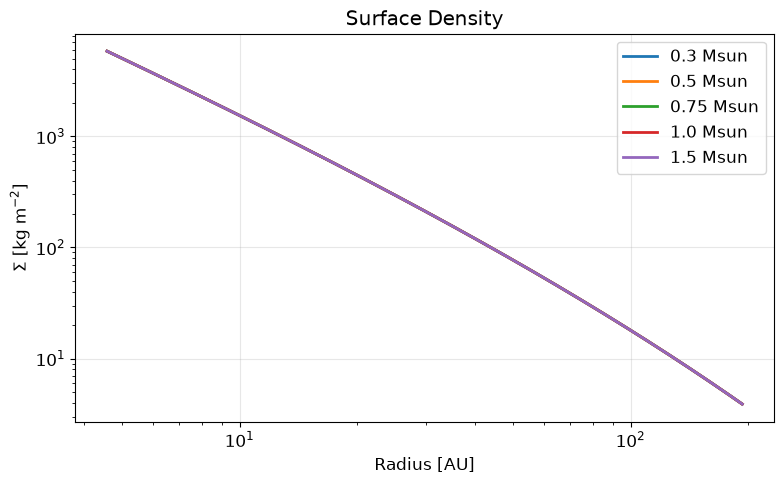

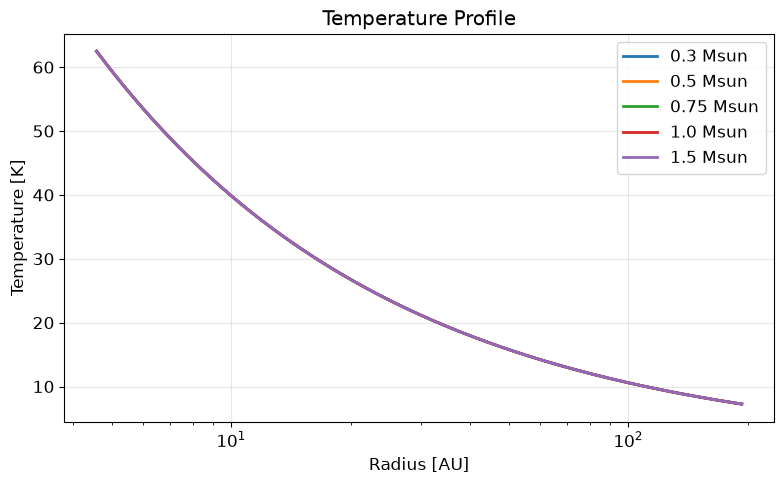

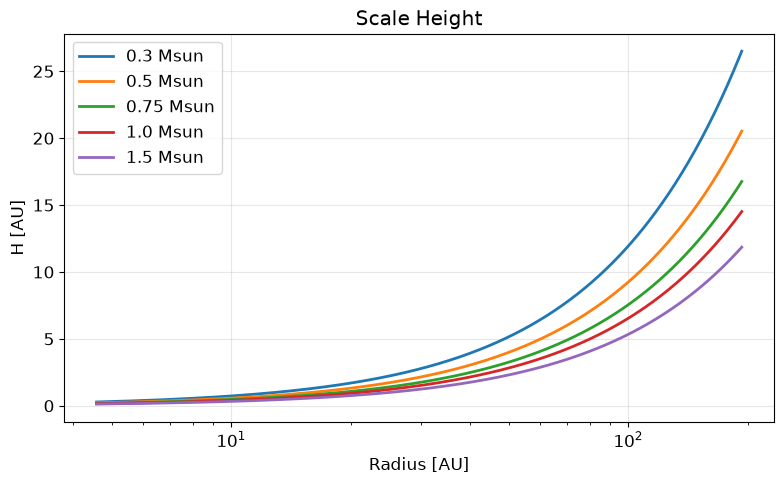

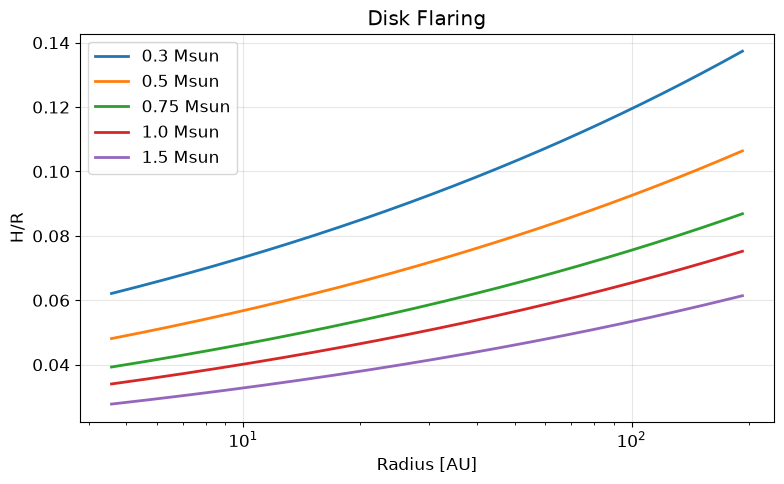

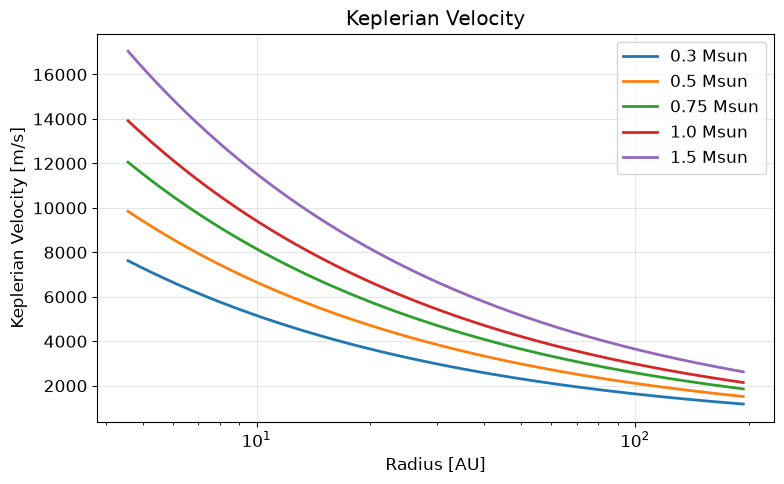

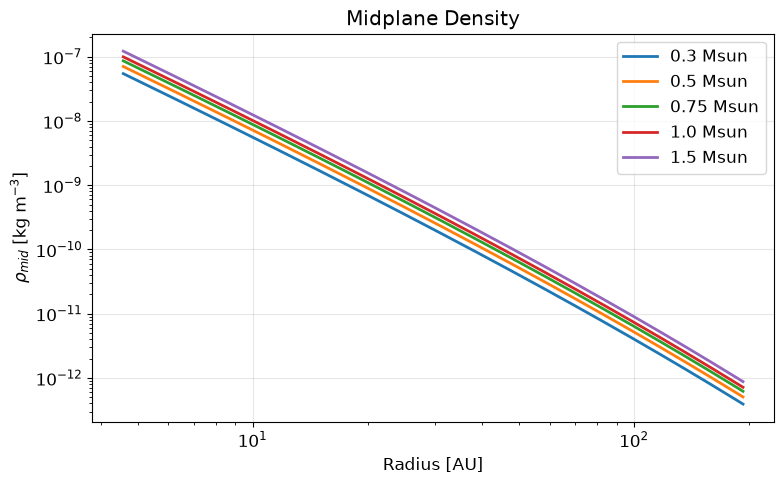

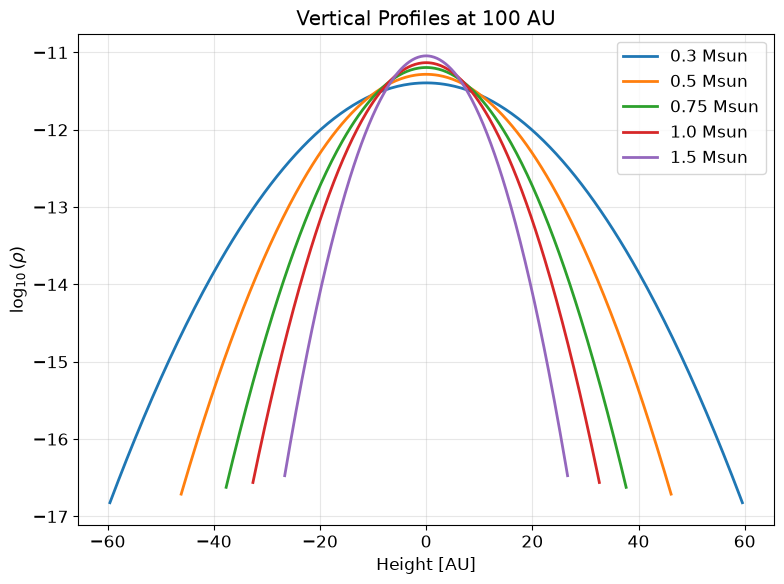

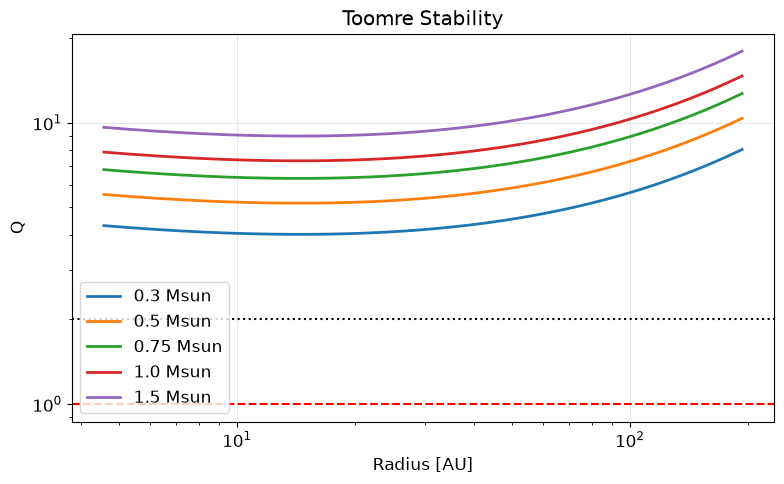

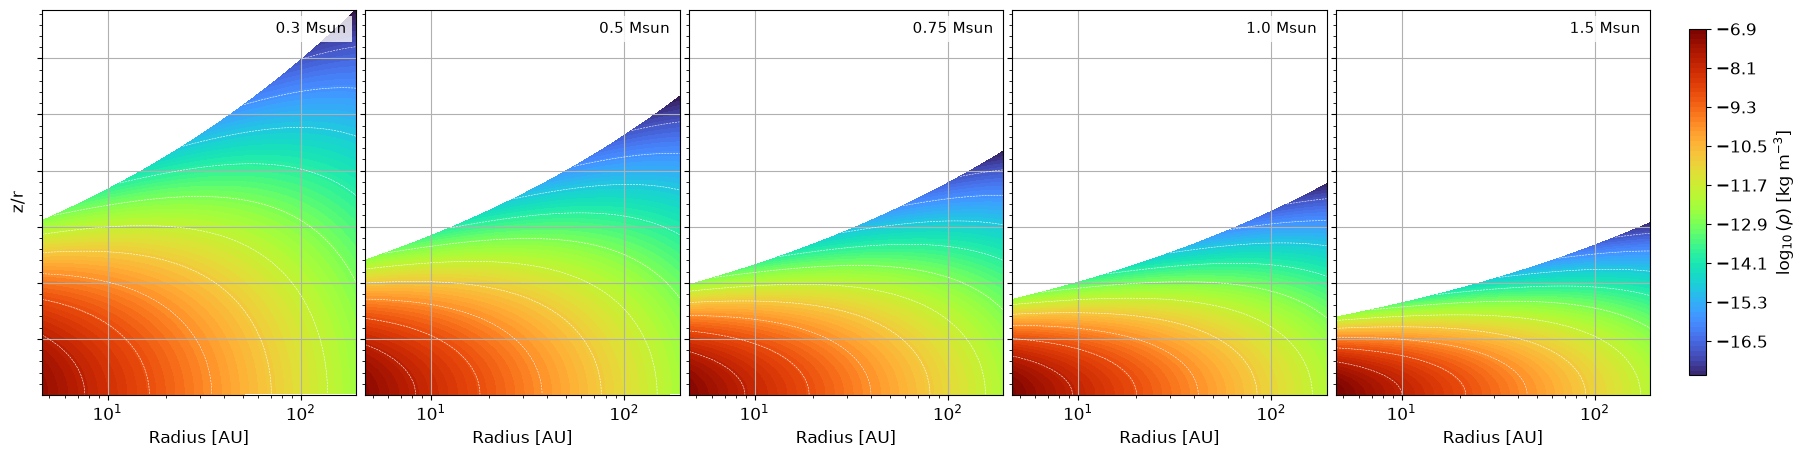

In [17]:
masses = [0.3, 0.5, 0.75, 1.0, 1.5]

models, labels = parameter_sweep(
    default_parameters(),
    "MSTAR",
    masses
)

labels = [f"{m} Msun" for m in masses]

plot_structure(models, labels)

# Sweep surface density exponent gamma
Compare disk structure across a range of surface density profile slopes.


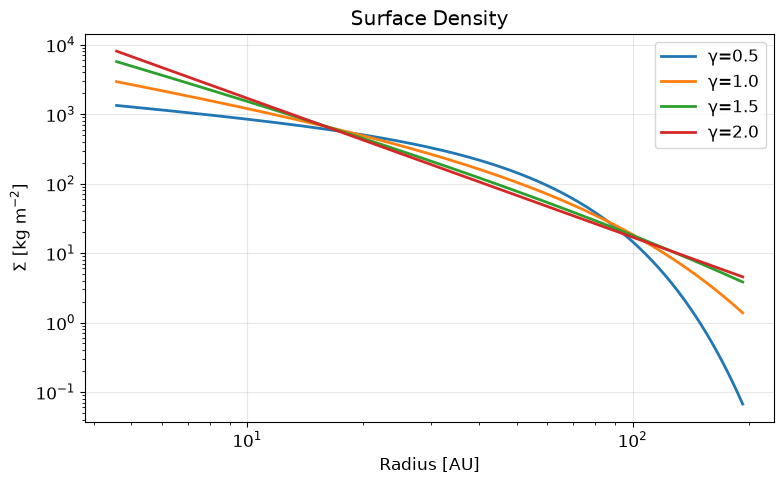

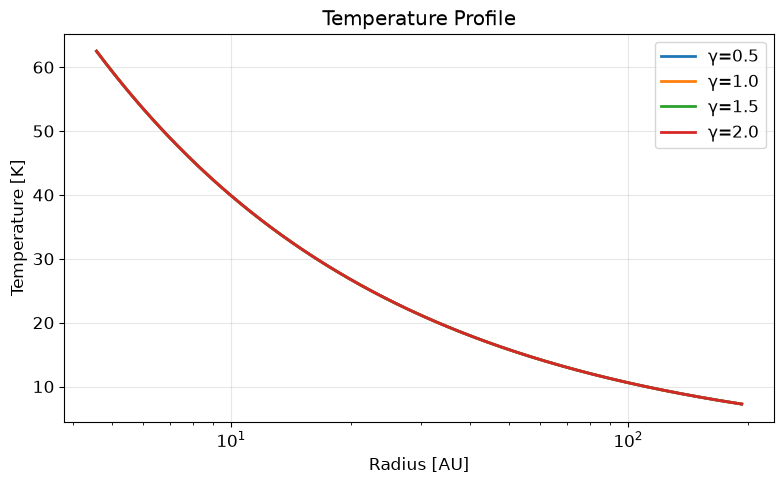

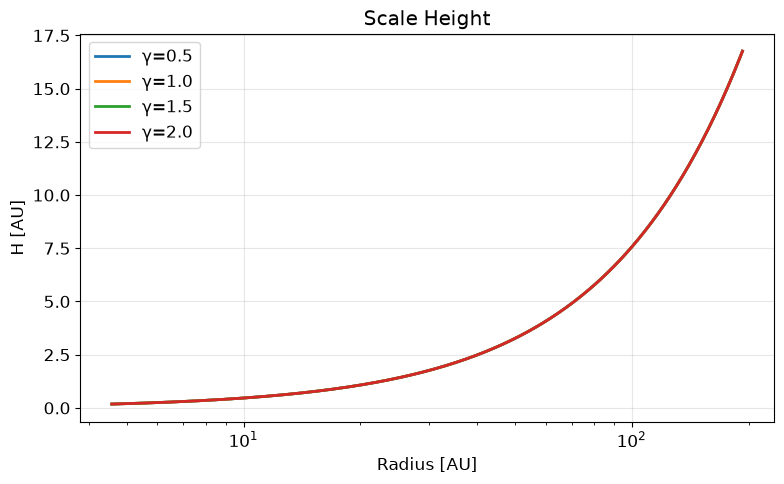

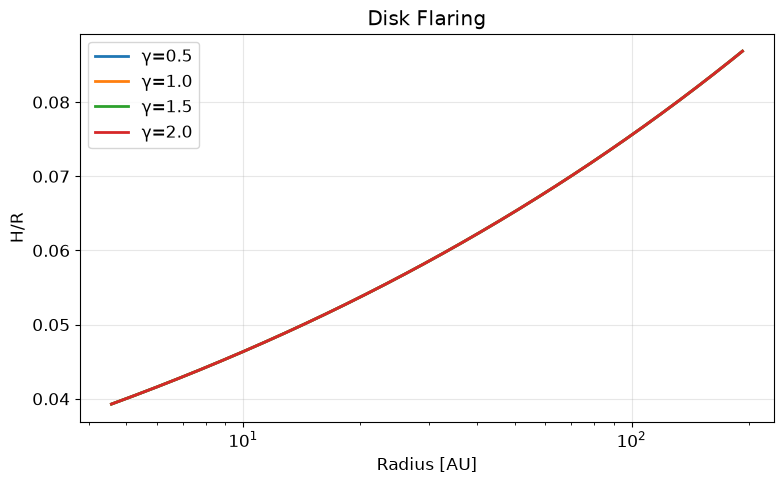

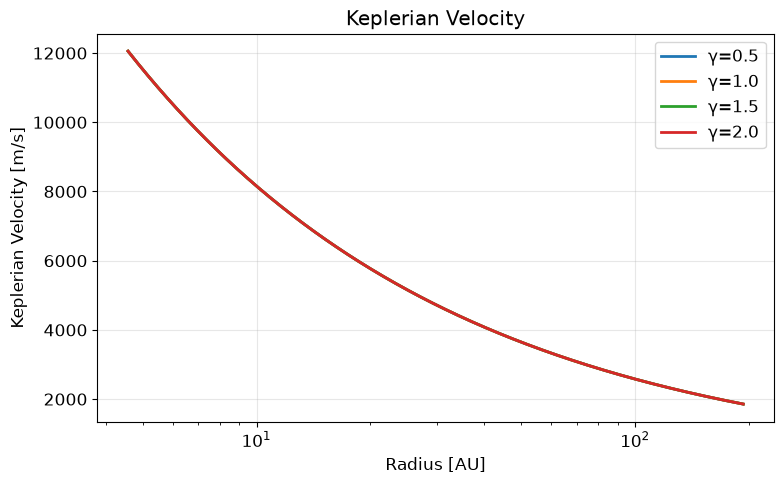

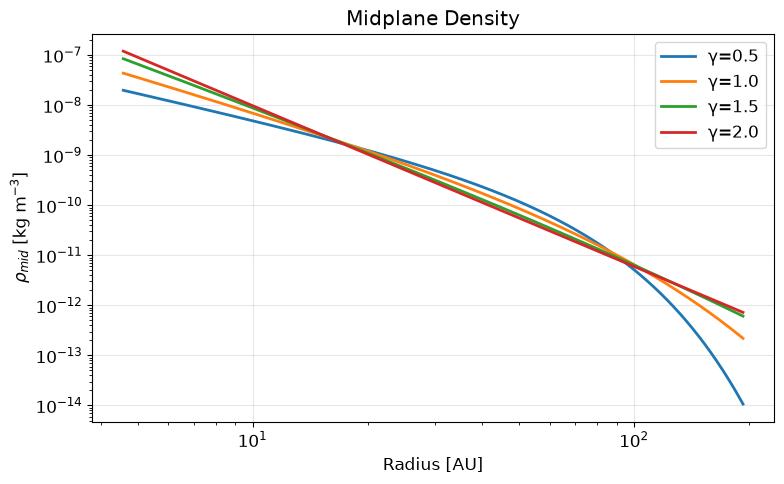

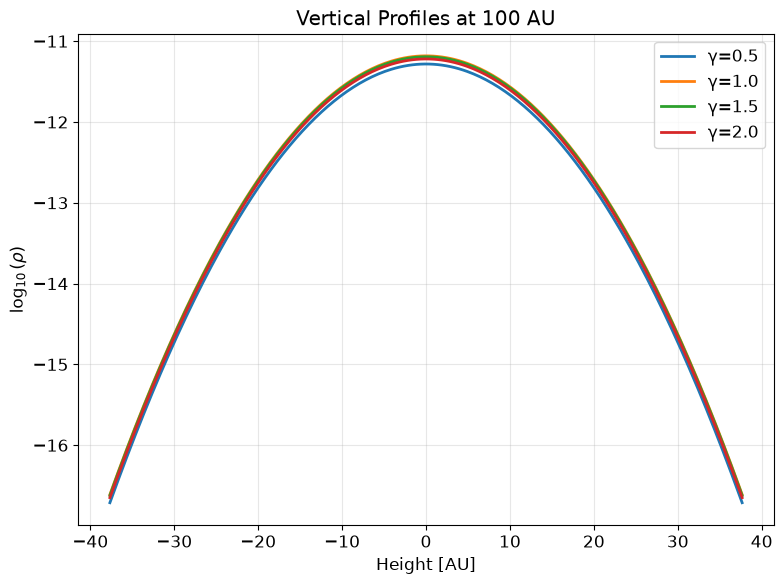

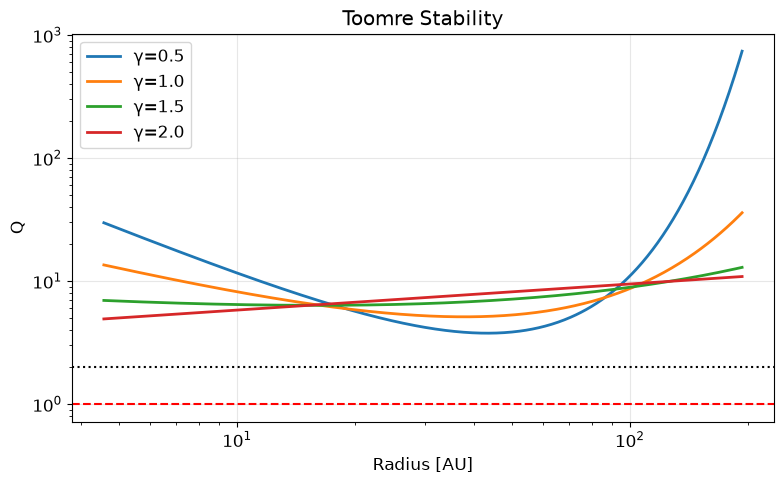

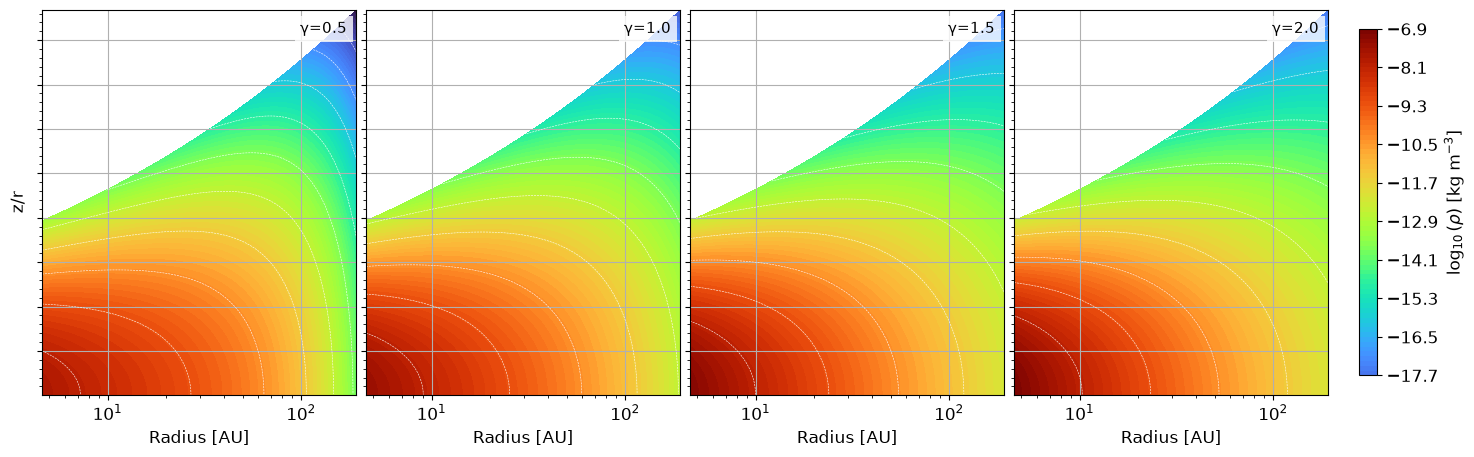

In [18]:
gammas=[0.5,1.0,1.5,2.0]

models,labels = parameter_sweep(
                    default_parameters(),
                    "GAMMA",
                    gammas
                )


labels=[f"γ={g}" for g in gammas]

plot_structure(models, labels)

# Sweep Temperature exponent
Compare disk structure for different temperature exponents while holding all other parameters fixed.


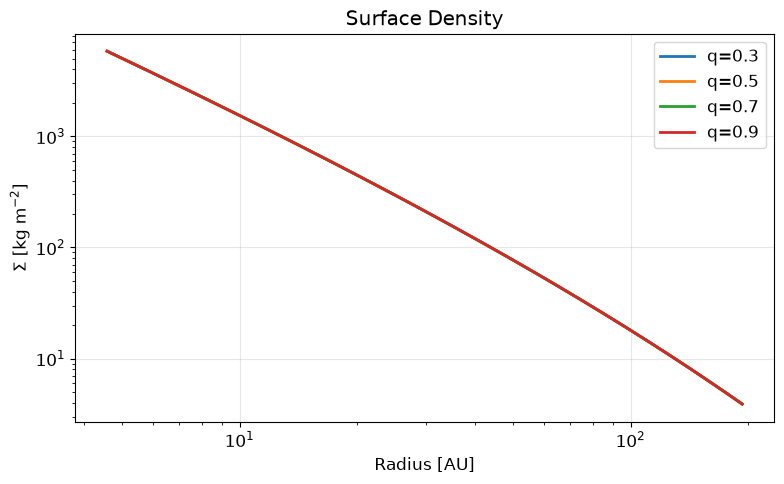

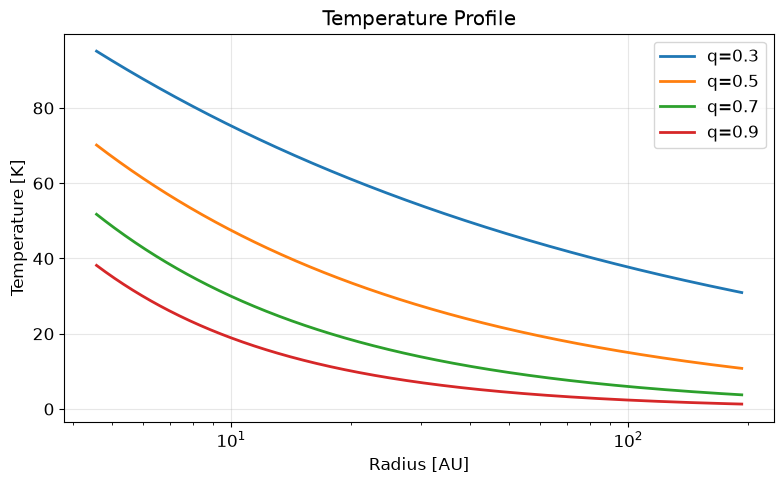

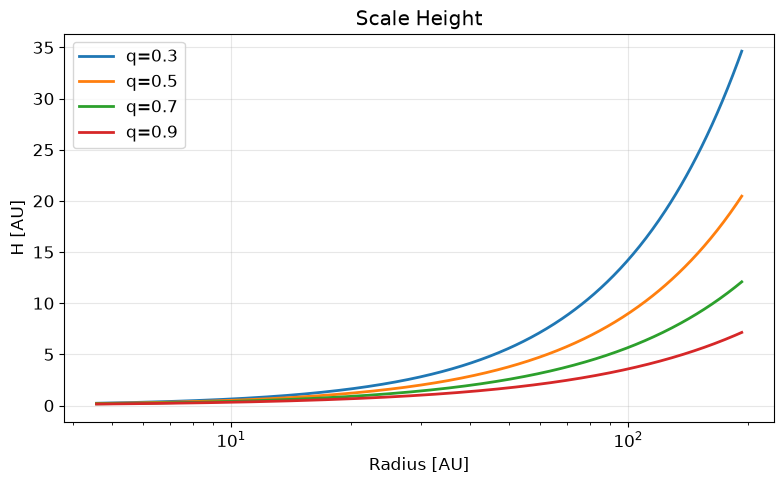

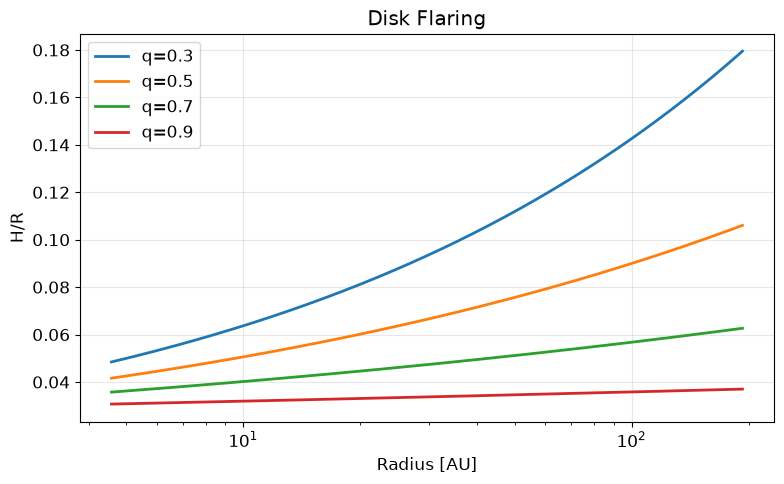

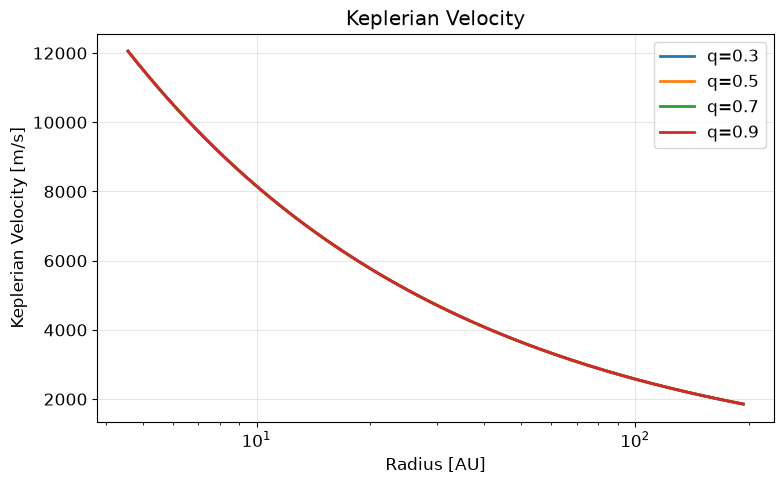

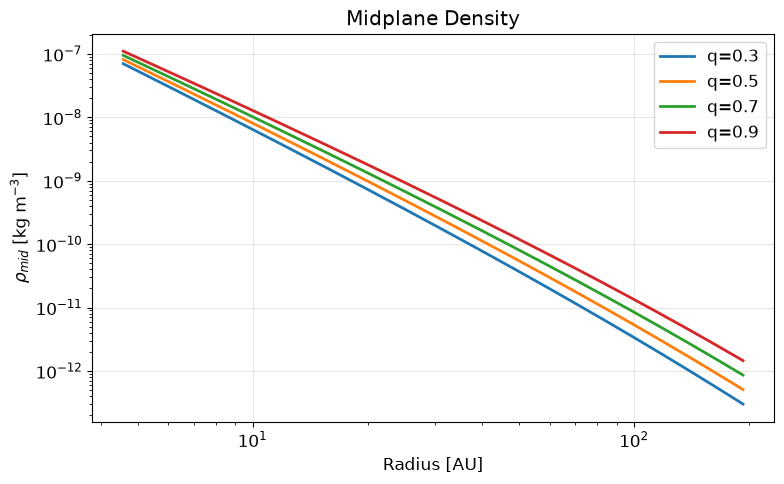

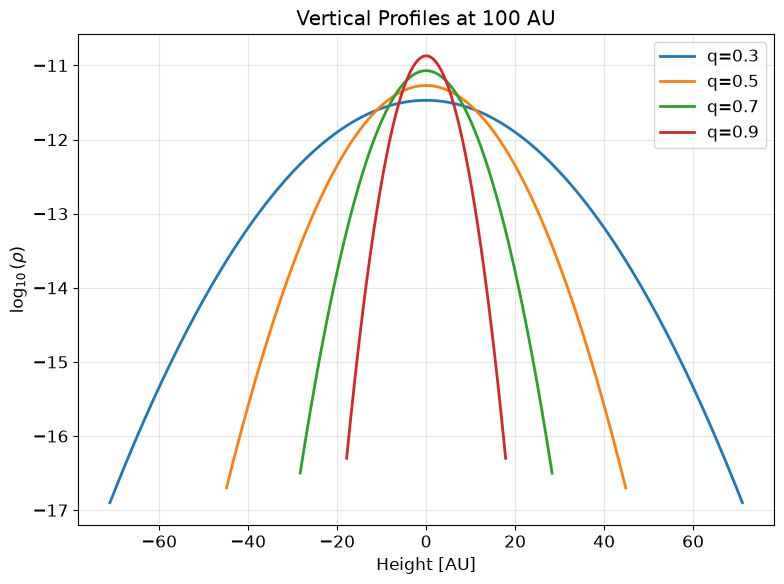

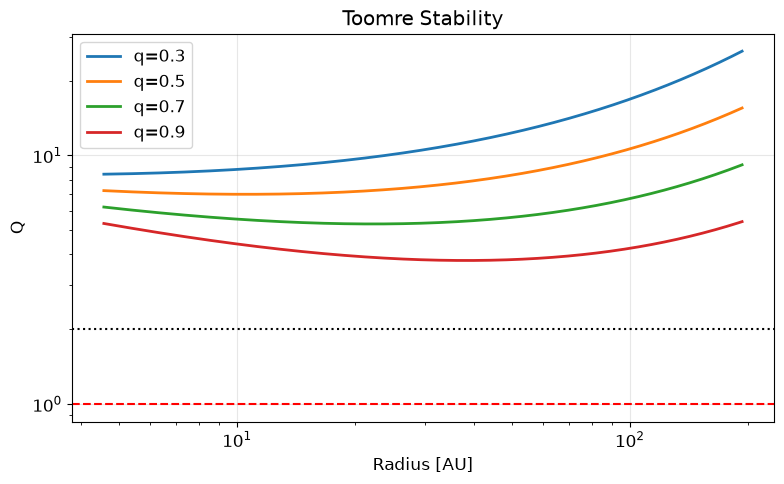

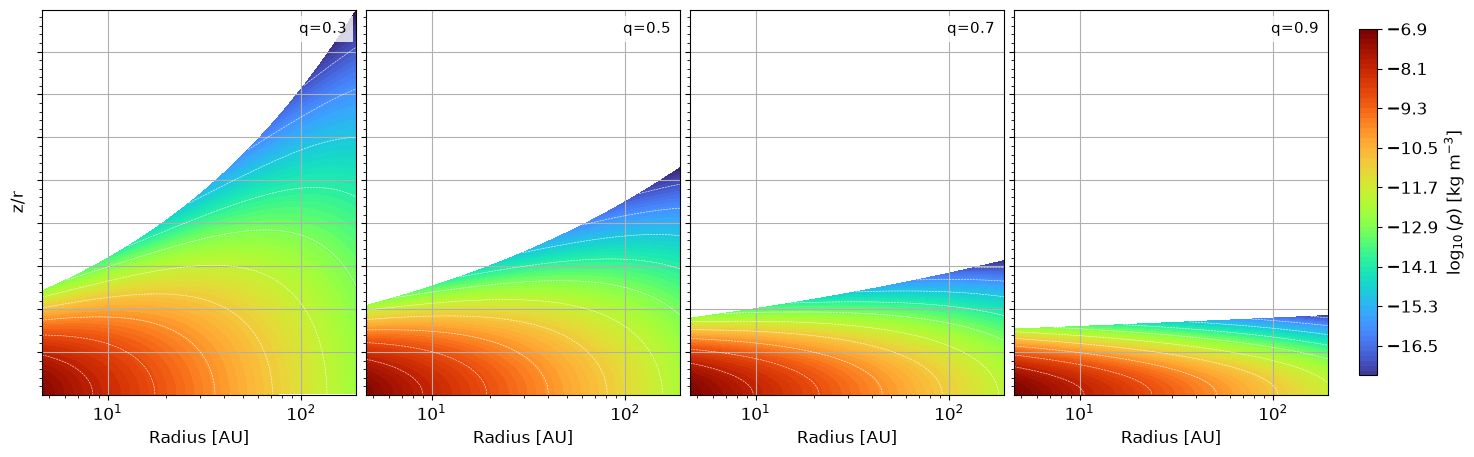

In [19]:
qs=[0.3,0.5,0.7,0.9]

models,labels = parameter_sweep(
                    default_parameters(),
                    "Q",
                    qs
                )


labels=[f"q={q}" for q in qs]

plot_structure(models, labels)

# Sweep temperature normalization T(0)
Compare how the disk structure changes with different reference temperatures.


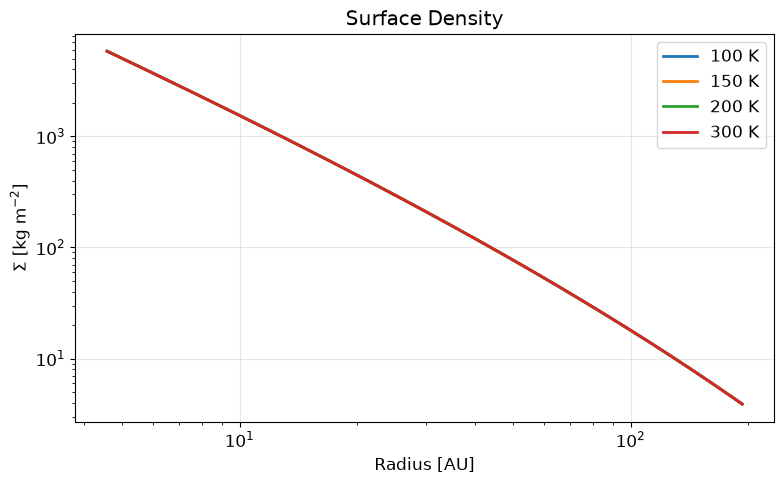

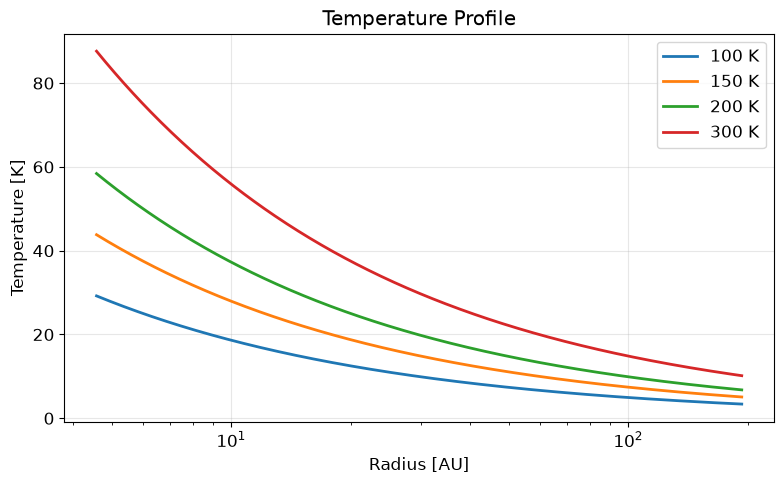

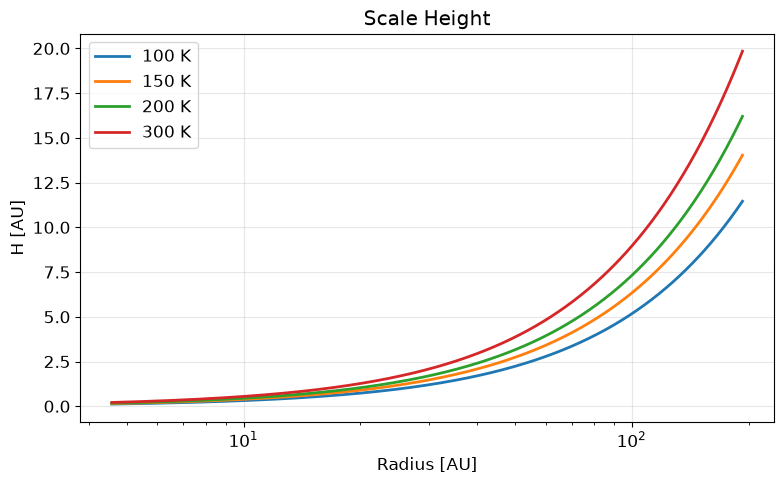

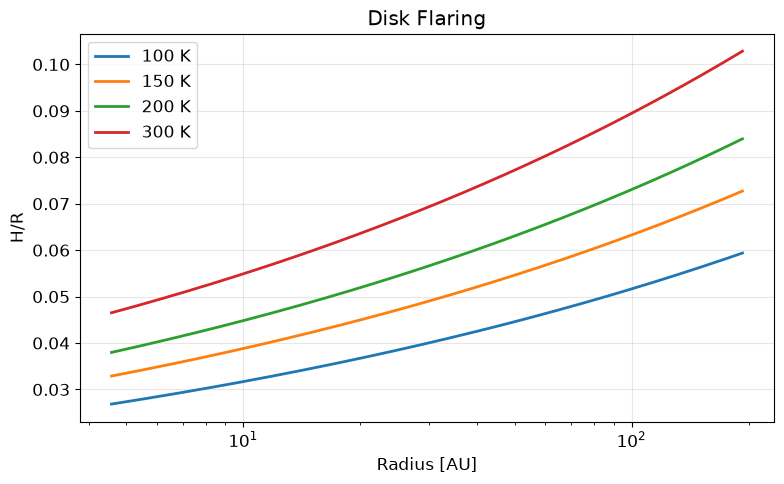

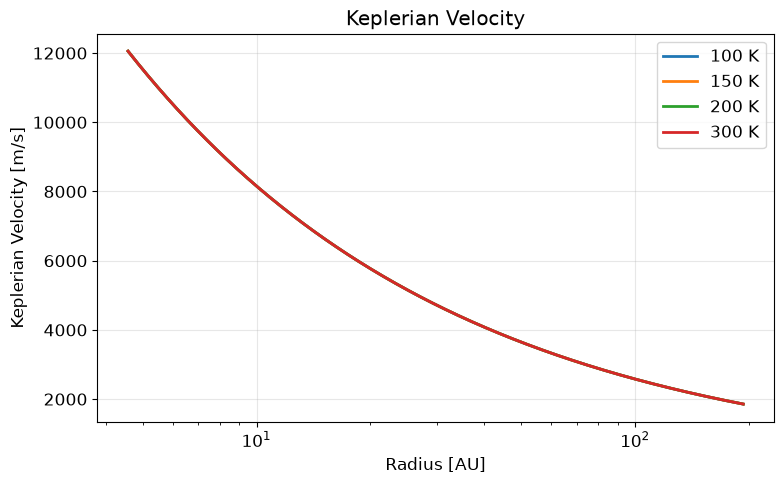

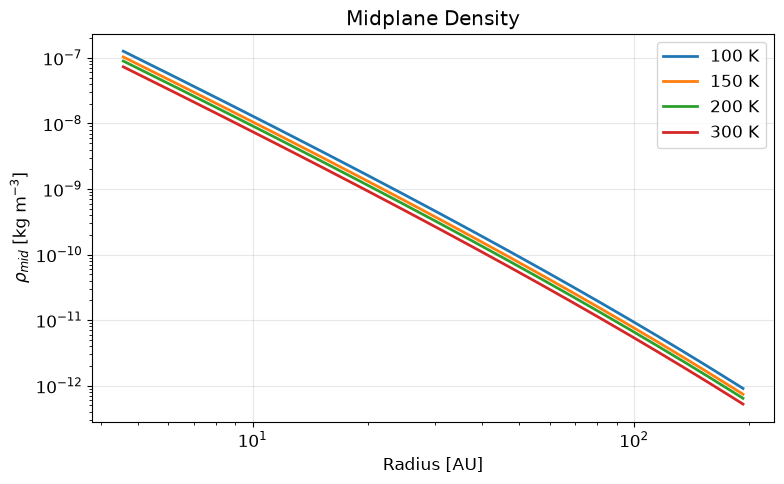

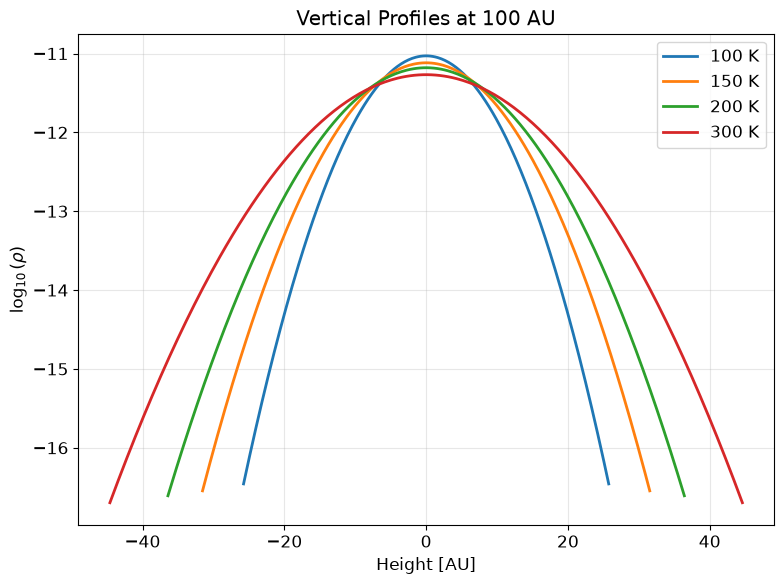

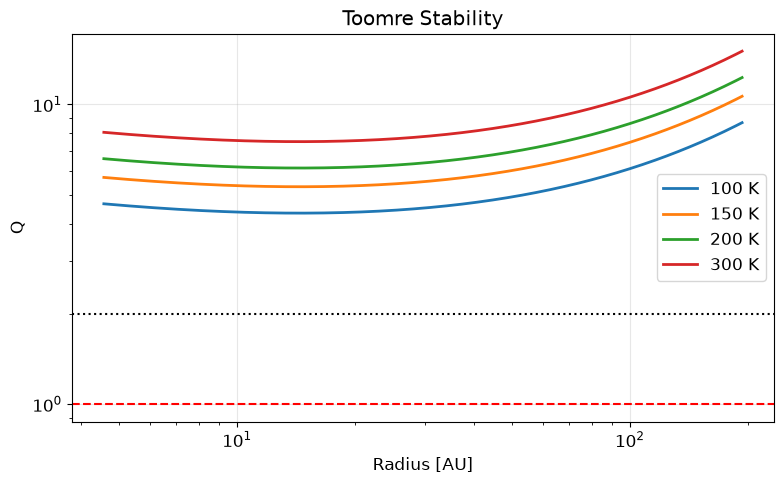

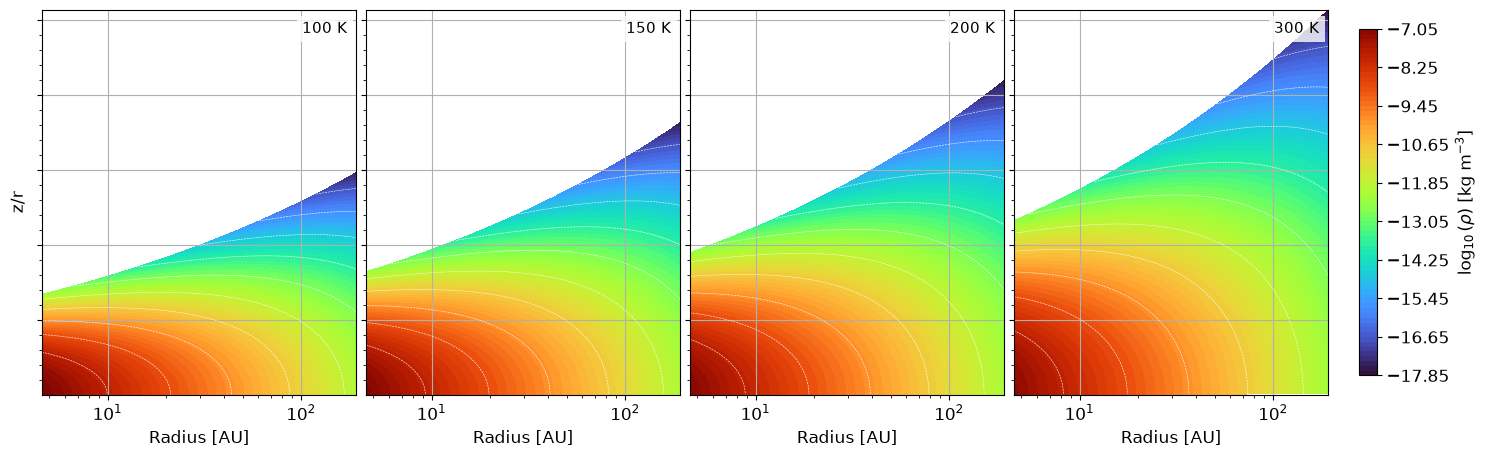

In [20]:
temps=[100,150,200,300]

models,labels = parameter_sweep(\
                    default_parameters(),
                    "T0",
                    temps
                )

labels=[f"{t} K" for t in temps]

plot_structure(models,labels)

# Sweep stellar luminosity
Compare disk structure for different stellar luminosities.


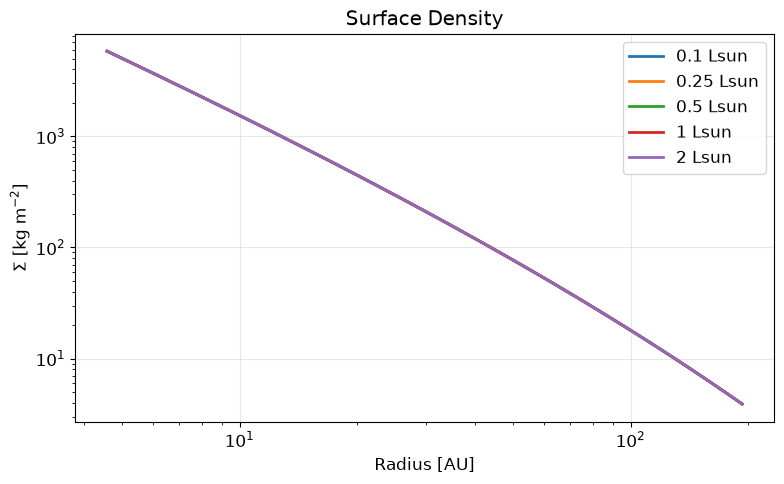

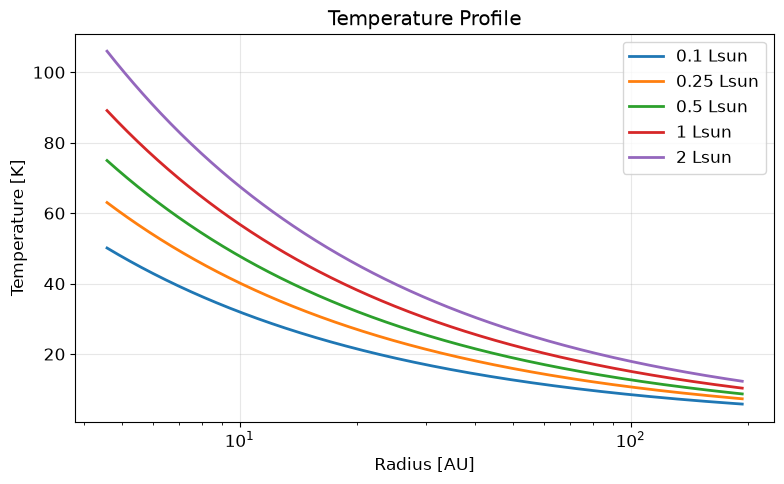

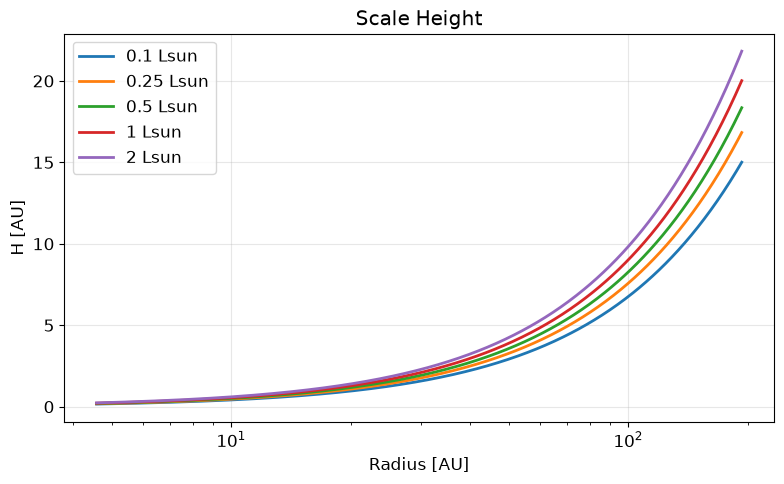

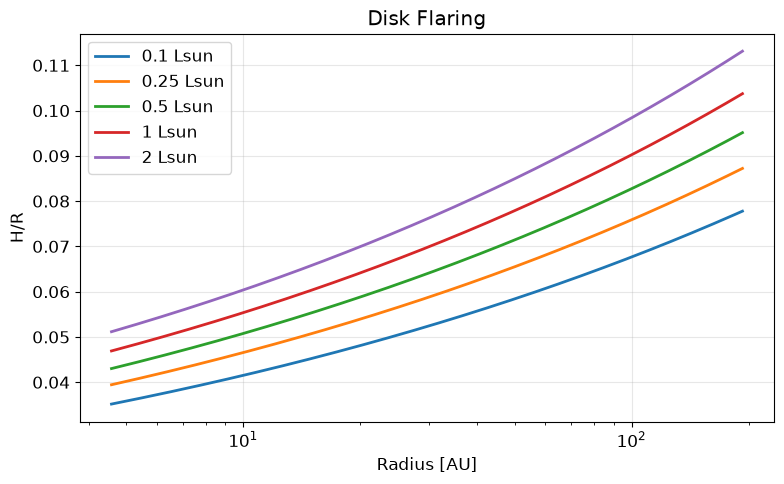

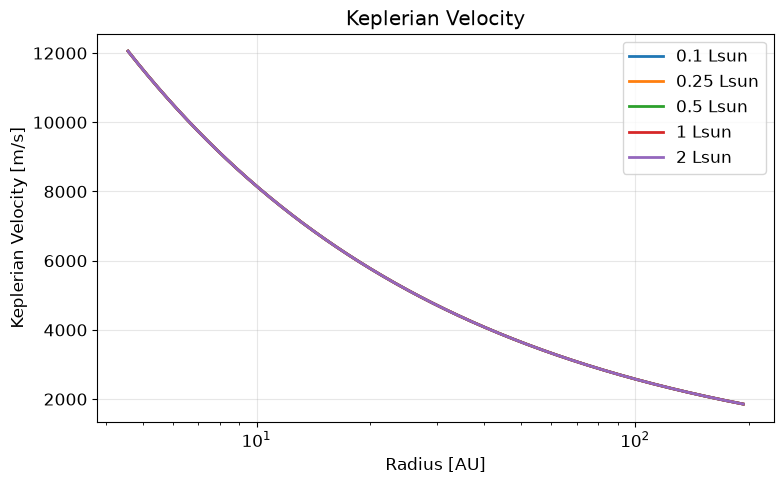

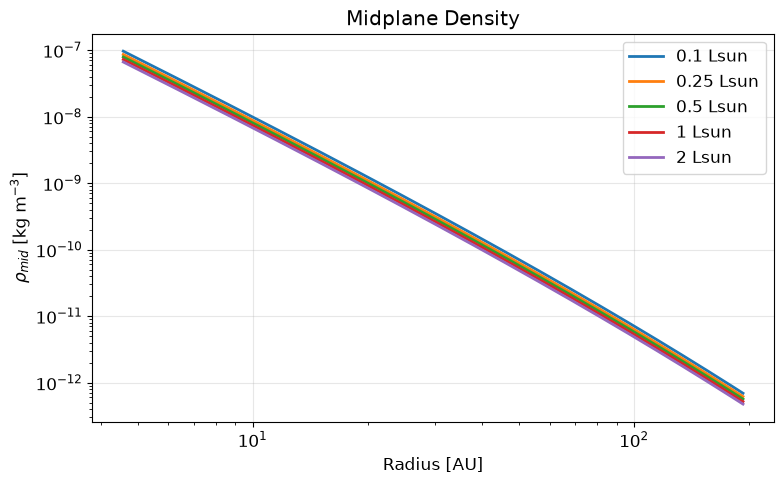

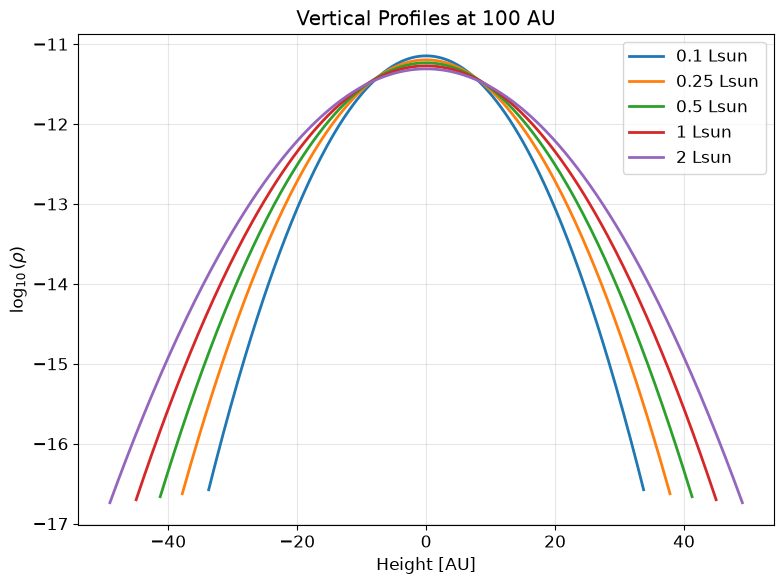

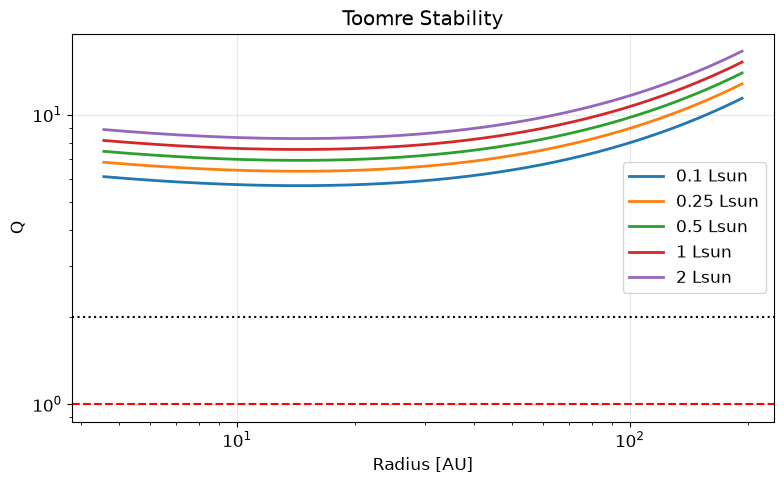

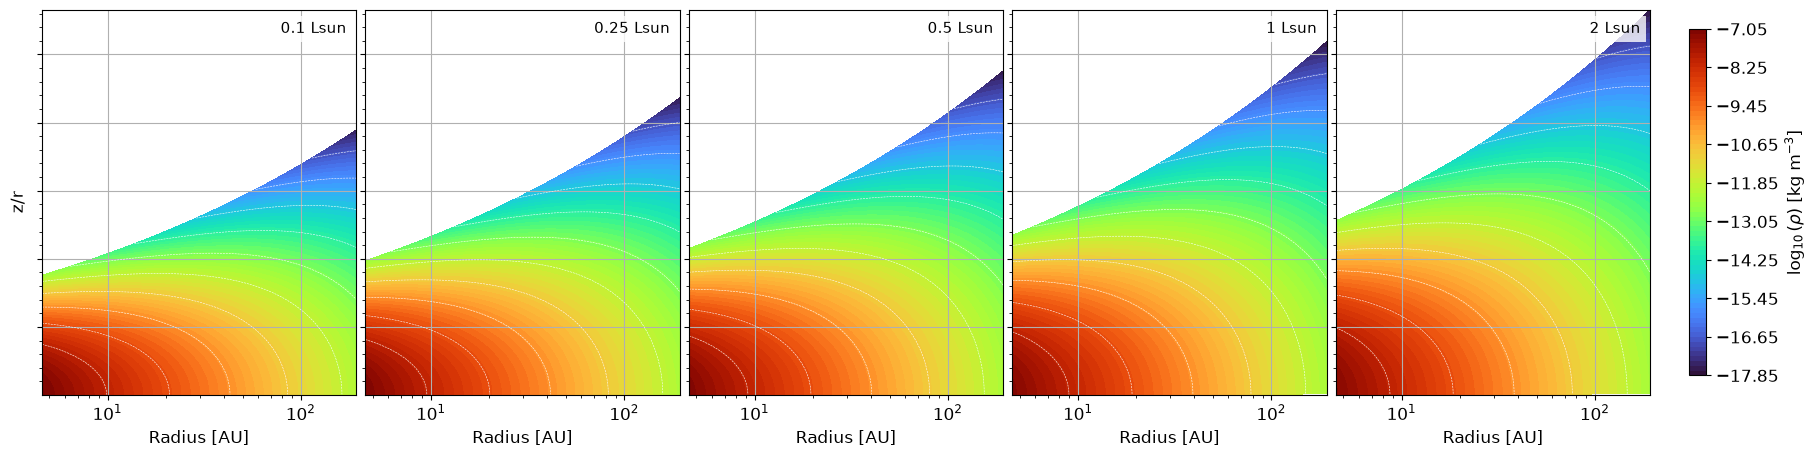

In [21]:
Lstars=[0.1,0.25,0.5,1,2]

models,labels = parameter_sweep(
                    default_parameters(),
                    "LSTAR",
                    Lstars
                )

labels=[f"{l} Lsun" for l in Lstars]

plot_structure(models,labels)

# Sweep outer disk radius
Compare disk structure as the outer disk radius is varied.


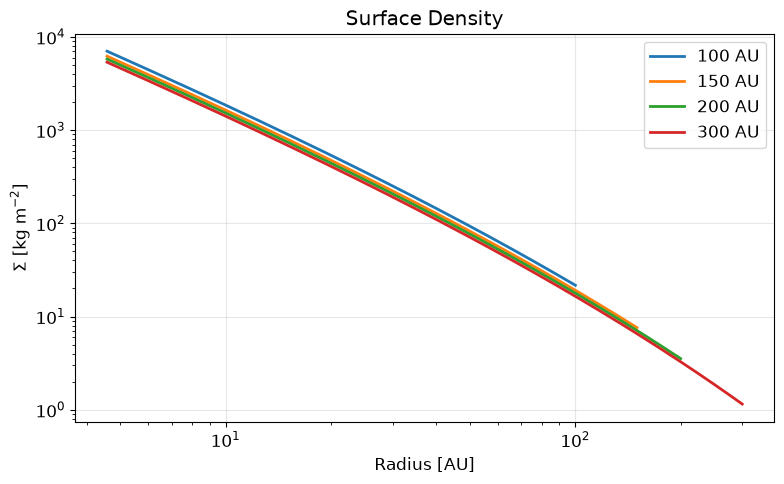

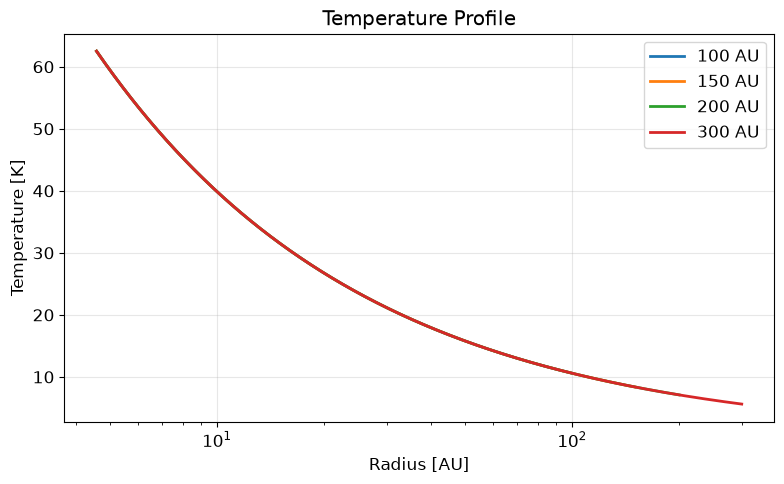

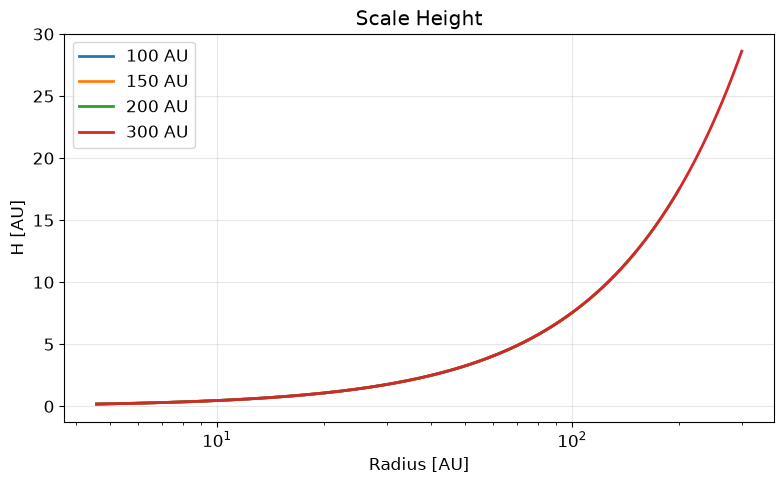

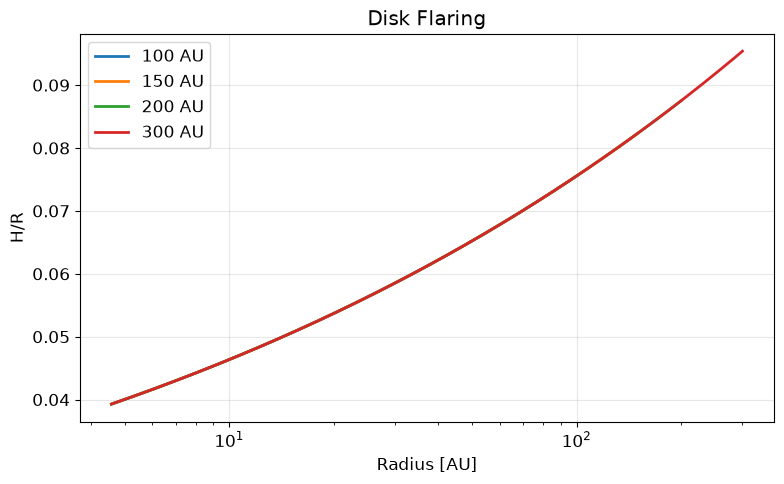

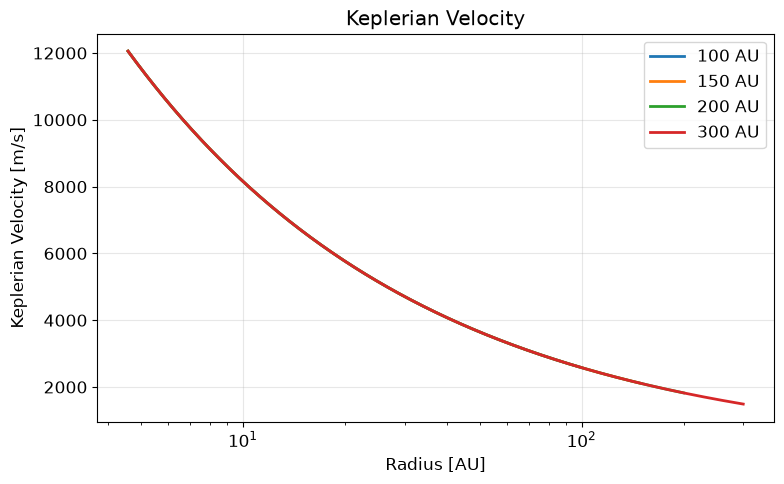

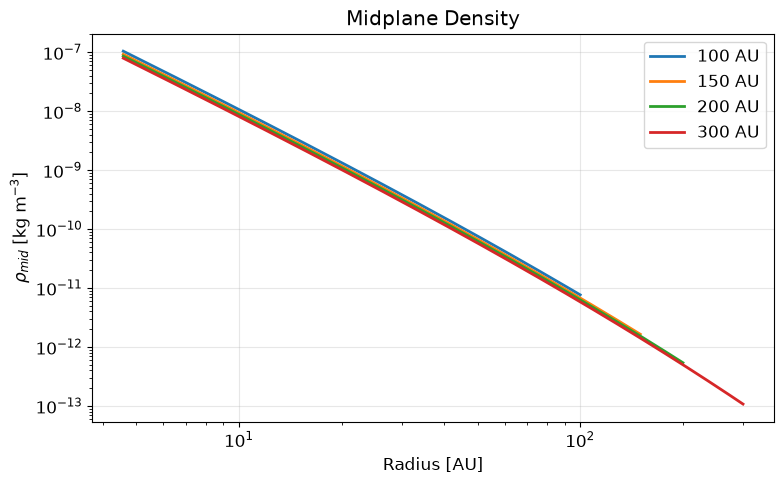

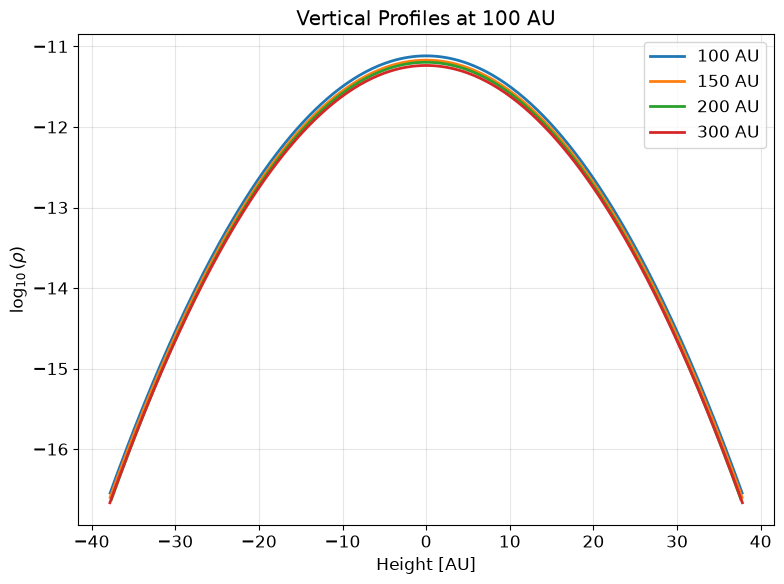

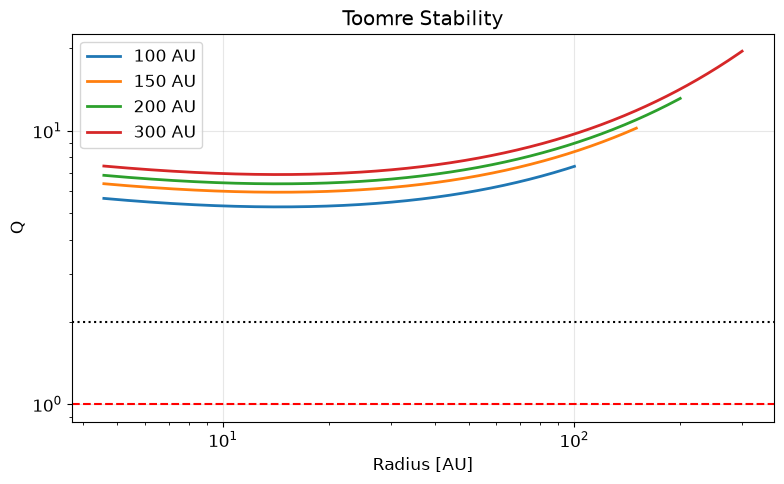

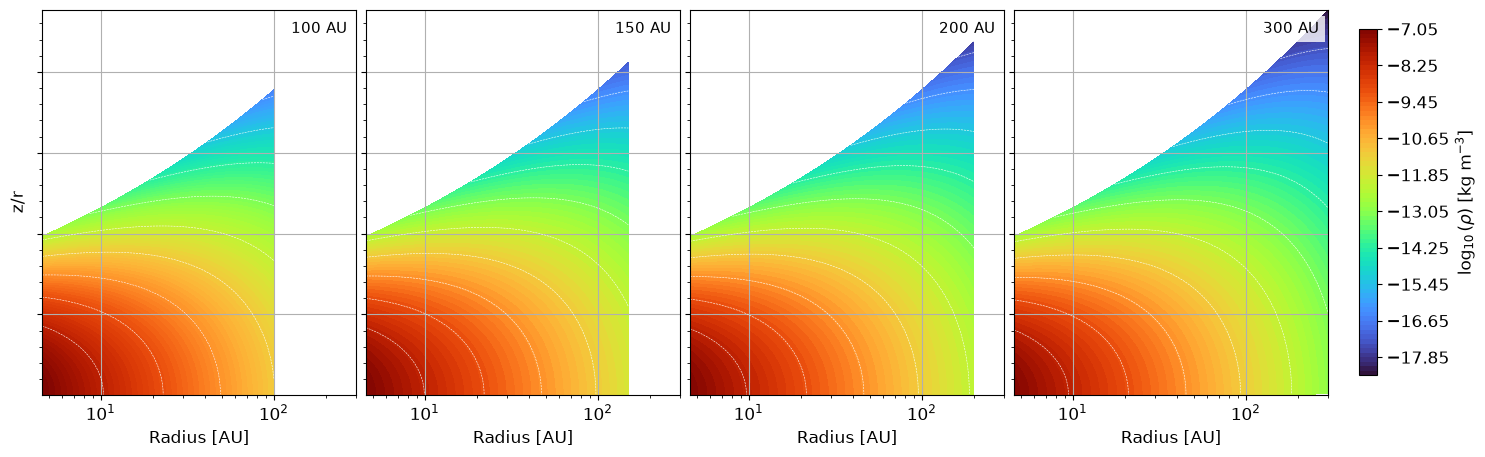

In [22]:
routs=[100,150,200,300]

models,labels = parameter_sweep(
                    default_parameters(),
                    "ROUT",
                    routs
                )

labels=[f"{r} AU" for r in routs]

plot_structure(models,labels)

# Sweep disk mass
Compare disk structure for different disk masses.


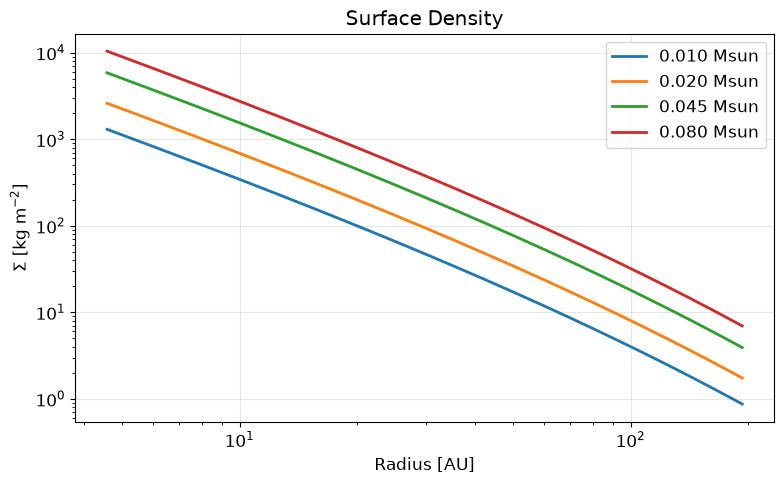

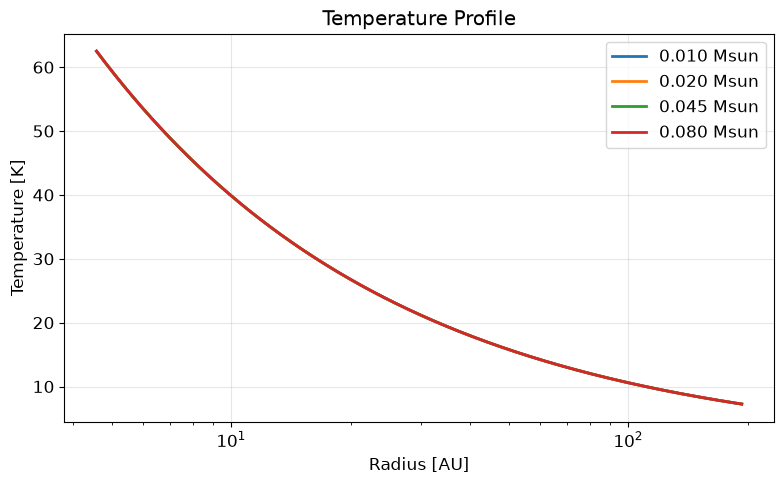

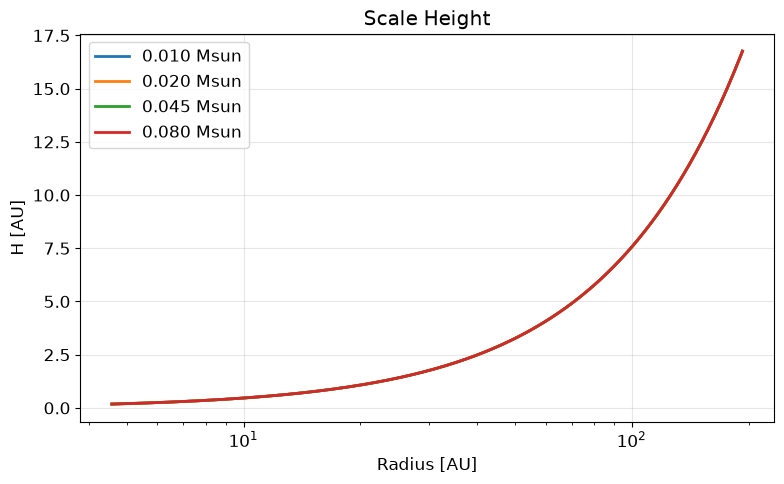

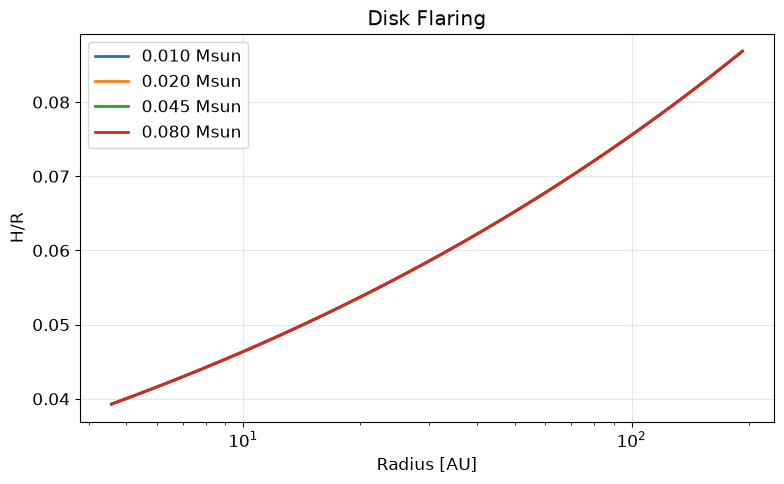

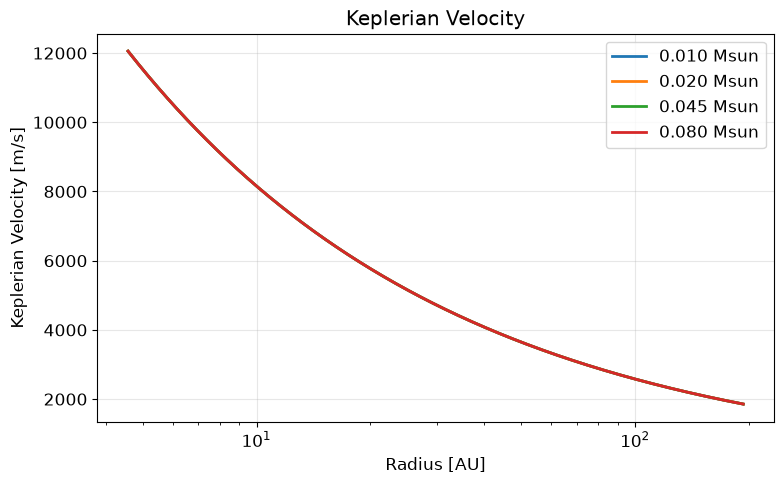

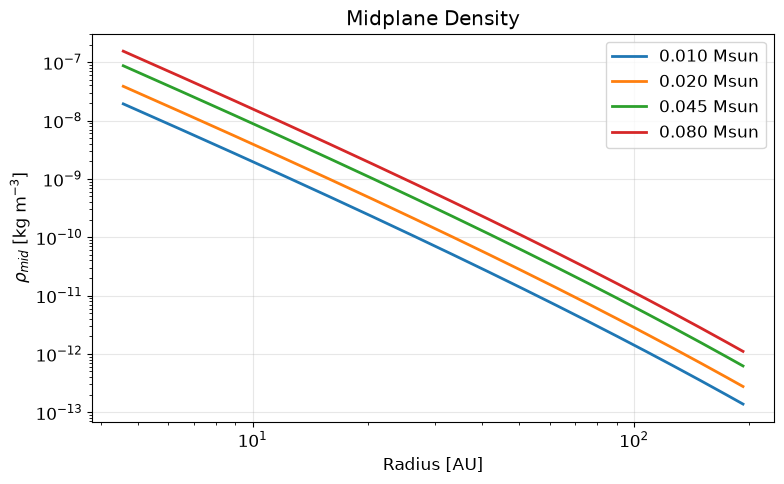

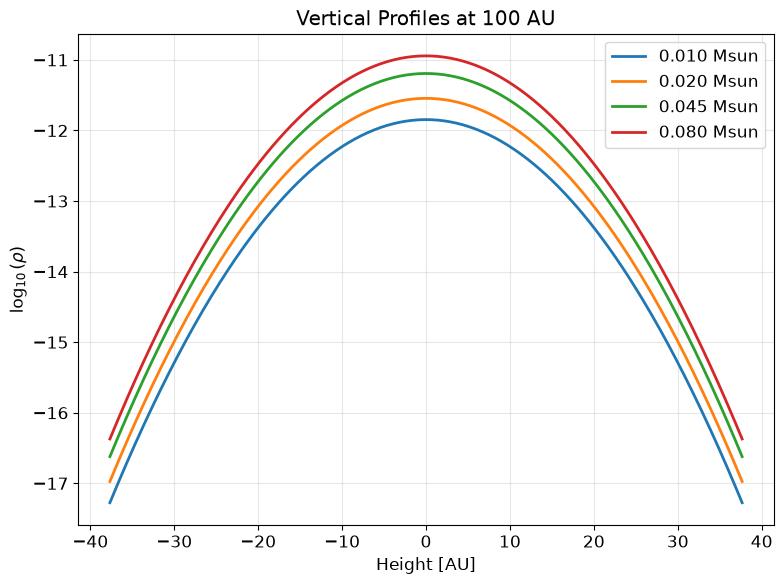

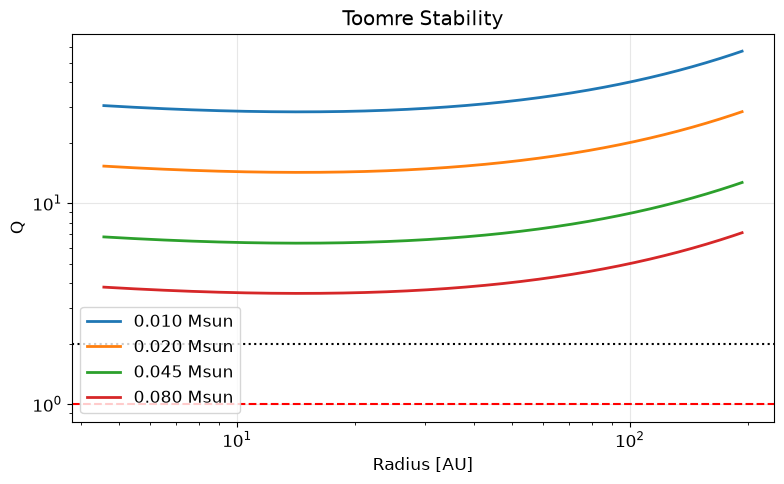

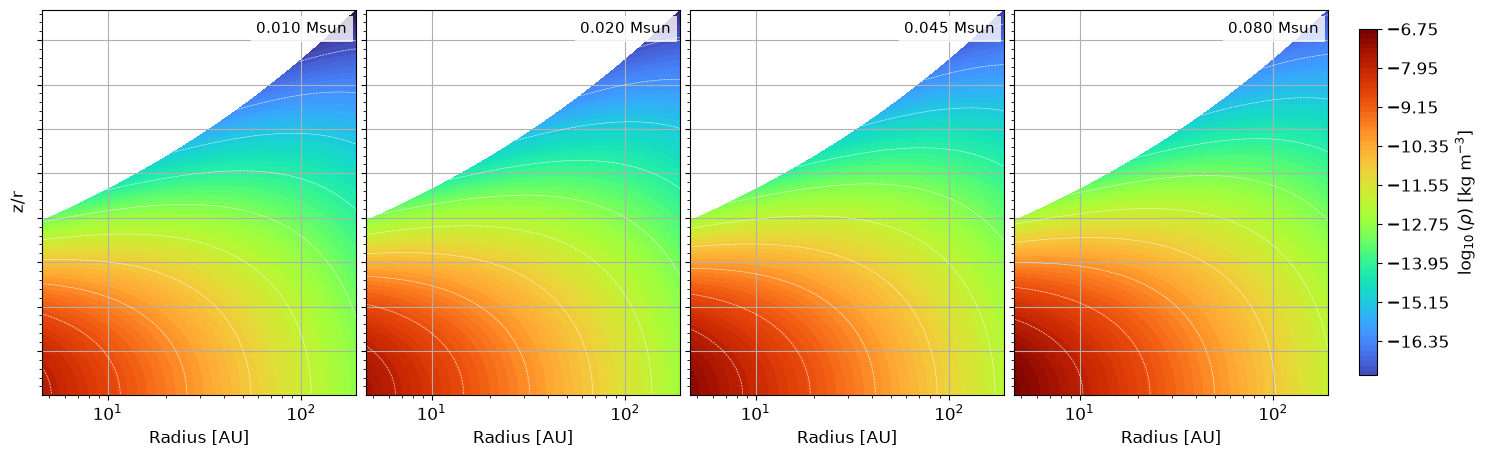

In [23]:
masses = [0.01,0.02,0.045,0.08]

models,labels = parameter_sweep(
    default_parameters(),
    "MDISK",
    masses
)

labels = [f"{m:.3f} Msun" for m in masses]

plot_structure(models,labels)

# Sweep characteristic radius
Compare the effects of varying the characteristic radius Rc on the disk profile.


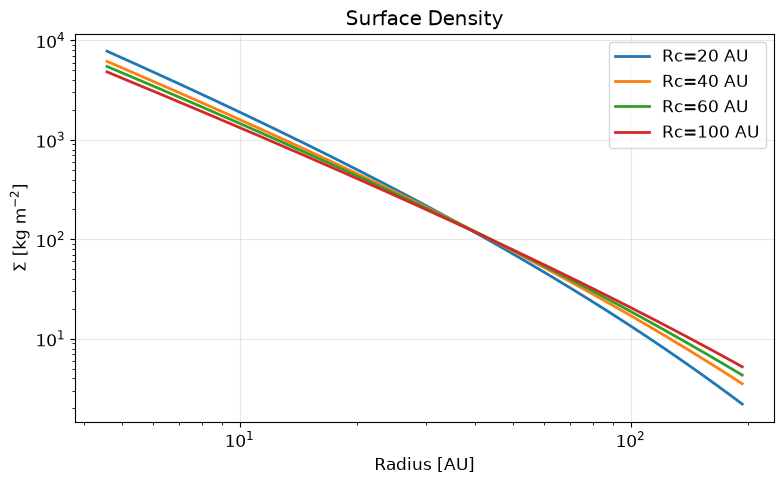

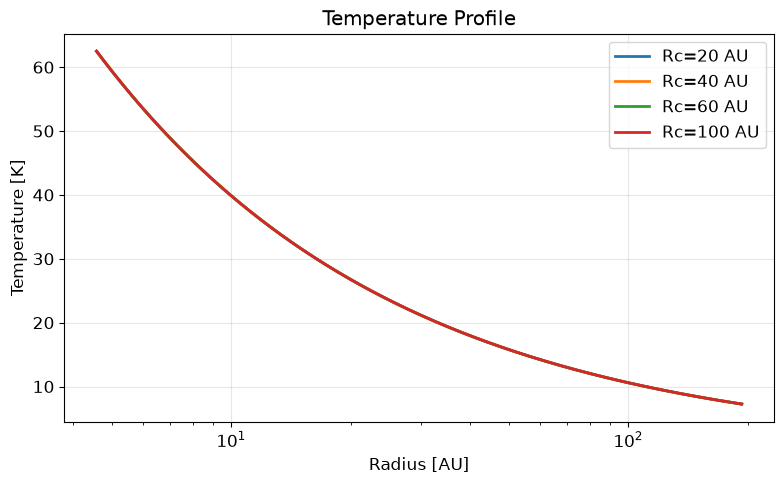

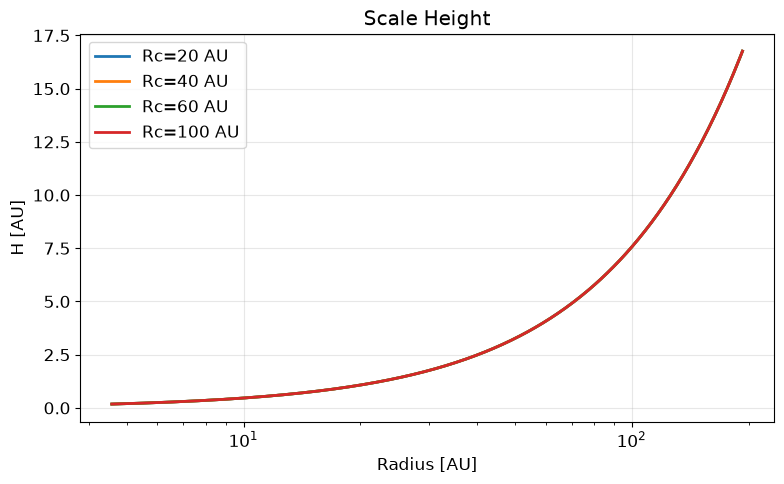

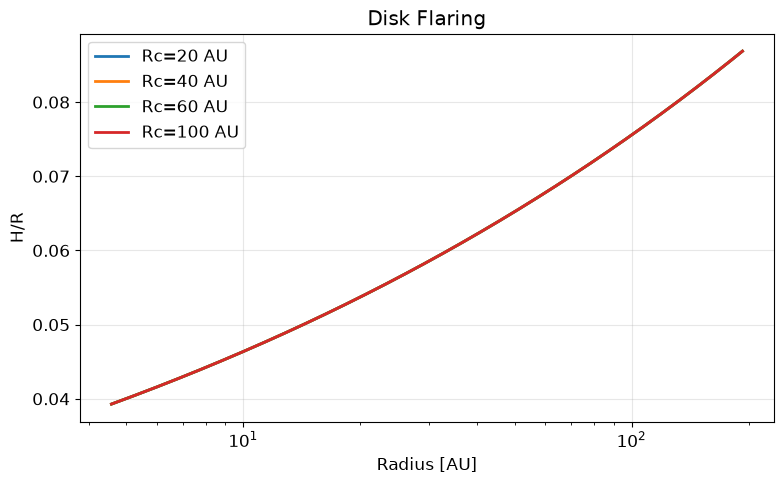

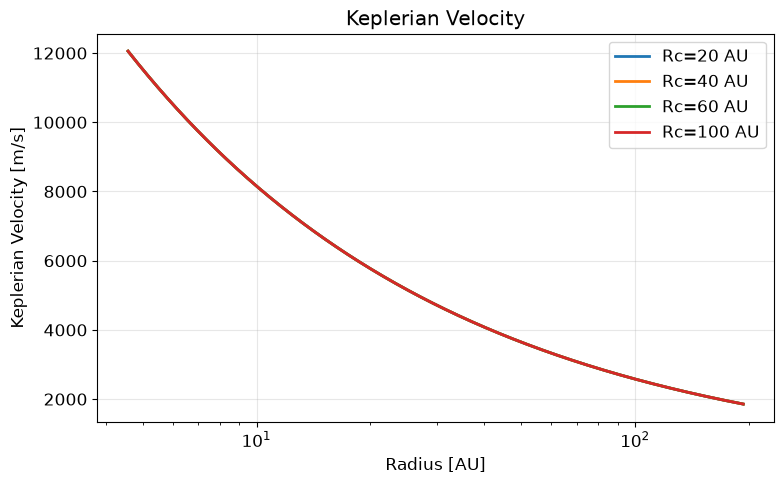

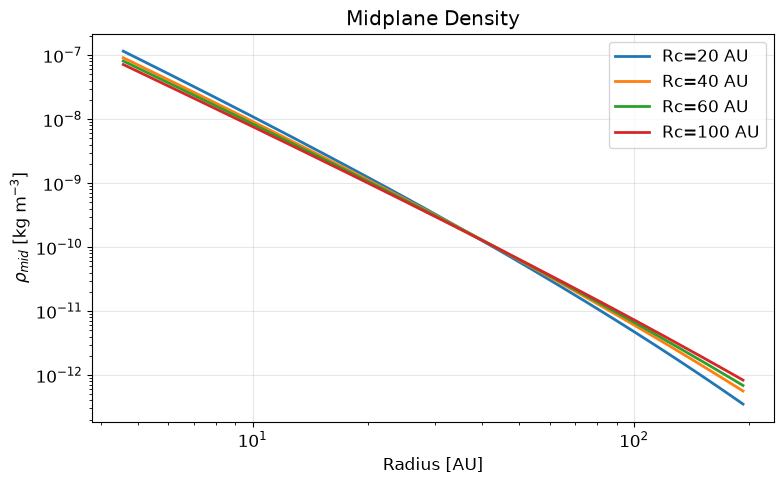

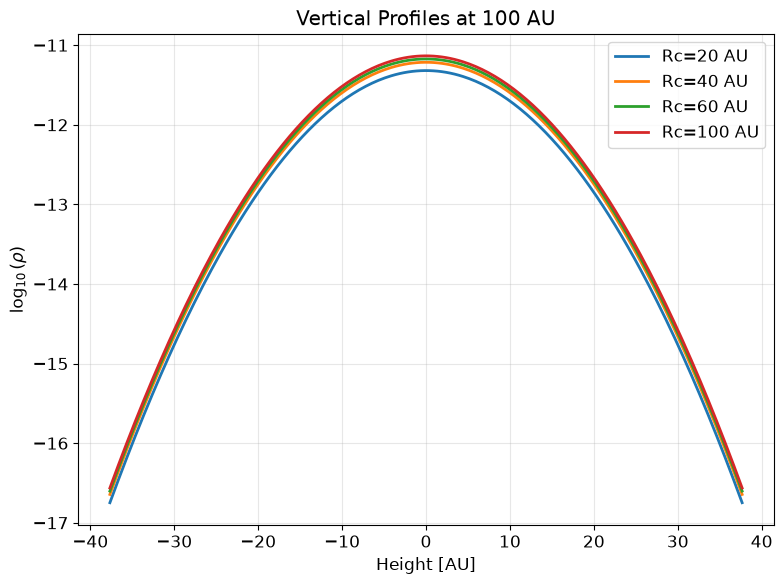

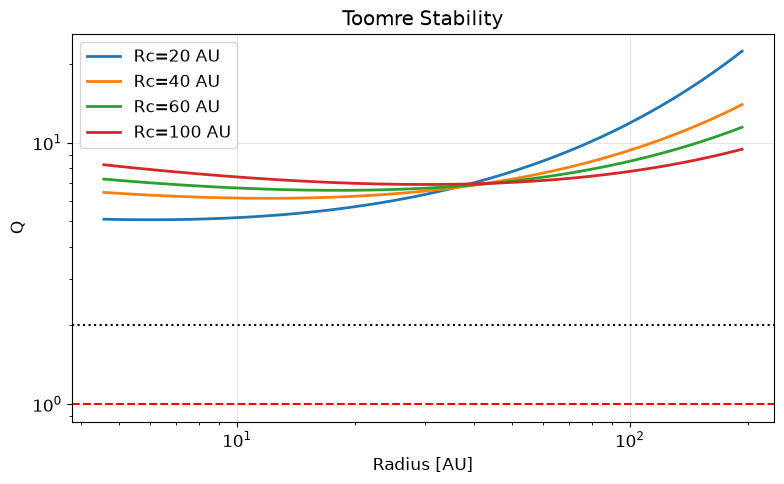

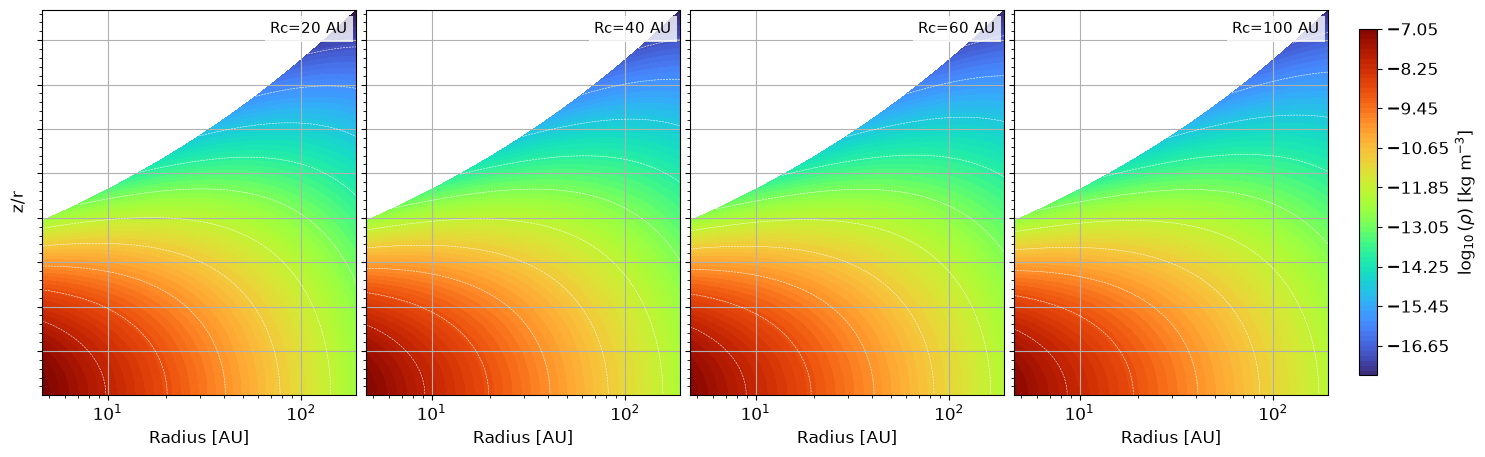

In [24]:
rcs=[20,40,60,100]

models,labels = parameter_sweep(
        default_parameters(),
        'RC',
        rcs
)

labels=[f'Rc={r} AU' for r in rcs]

plot_structure(models,labels)

# Compare observed disk systems
Load several observed protoplanetary disk models and compare their structures.


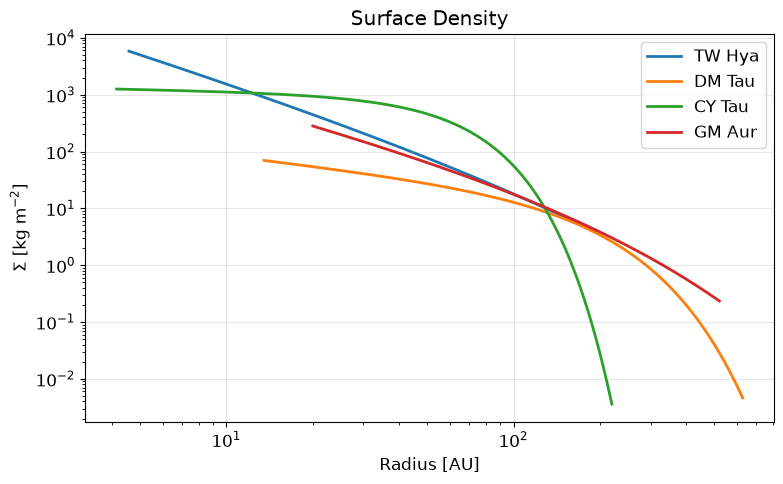

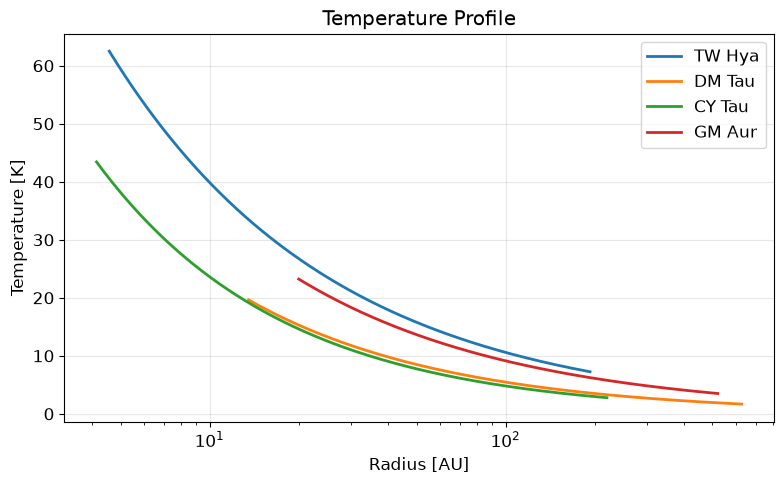

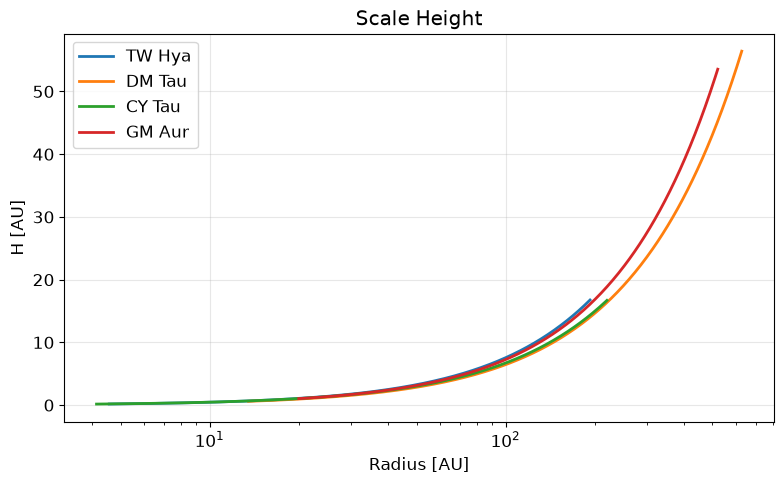

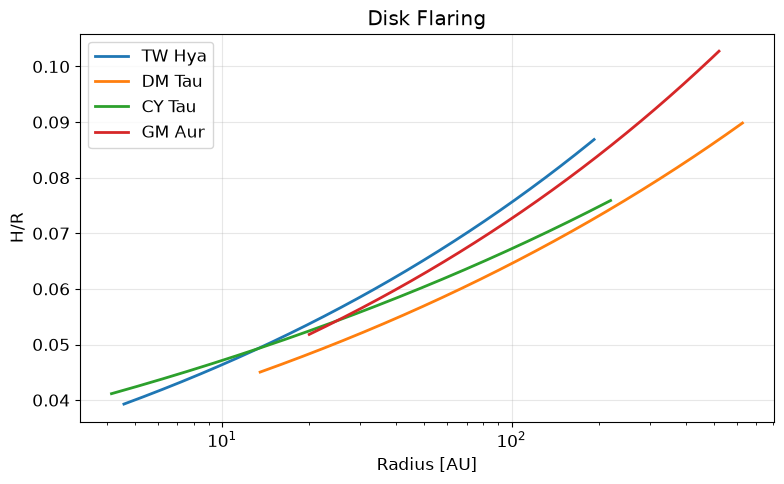

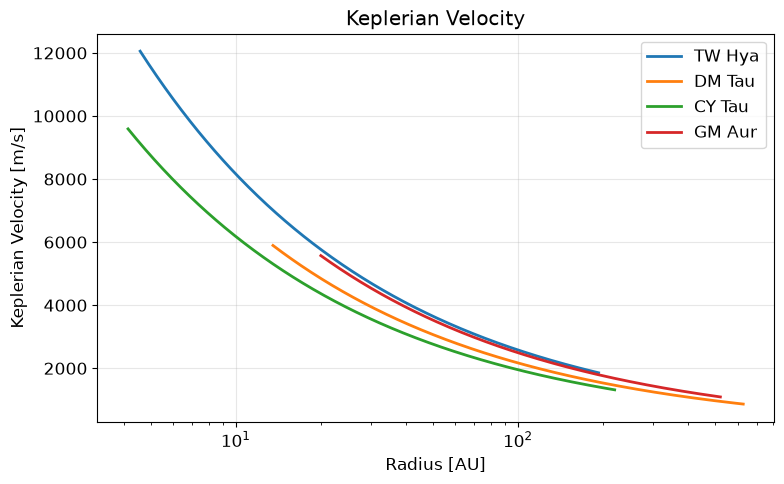

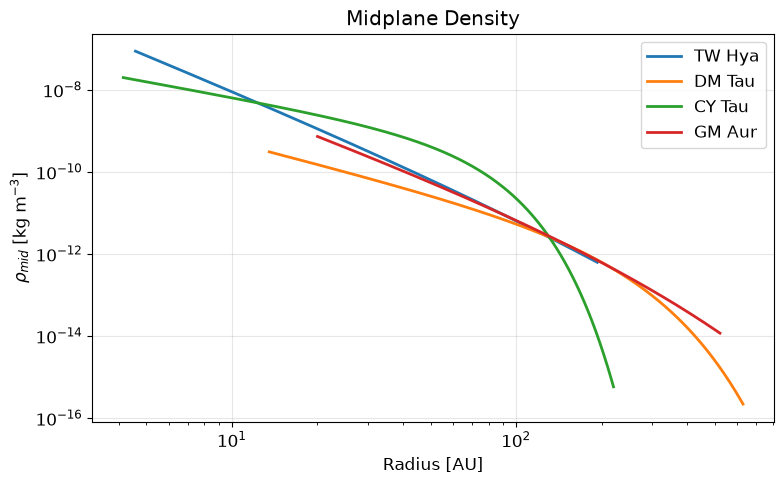

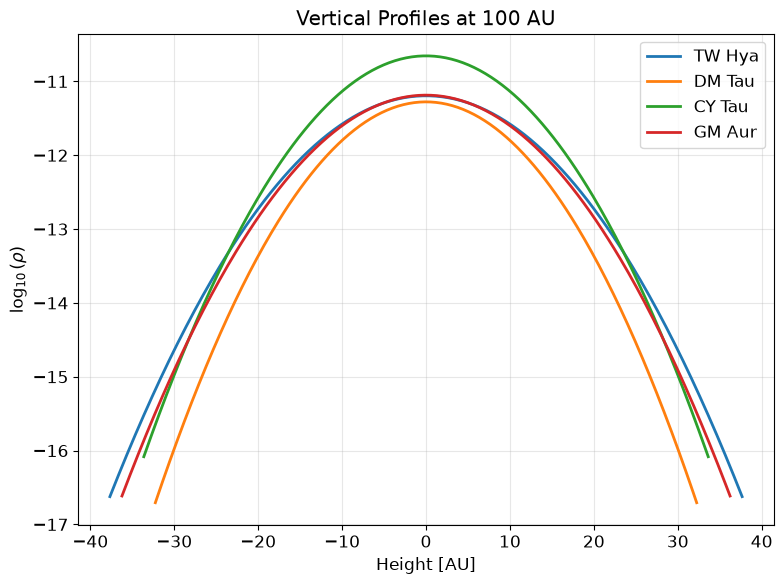

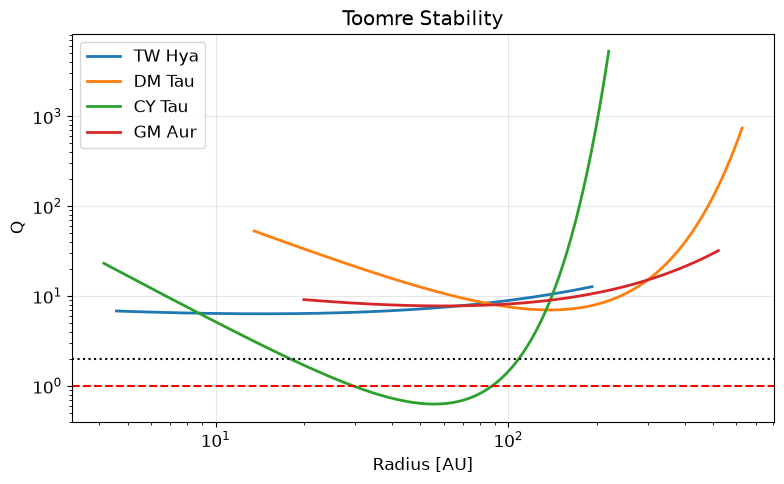

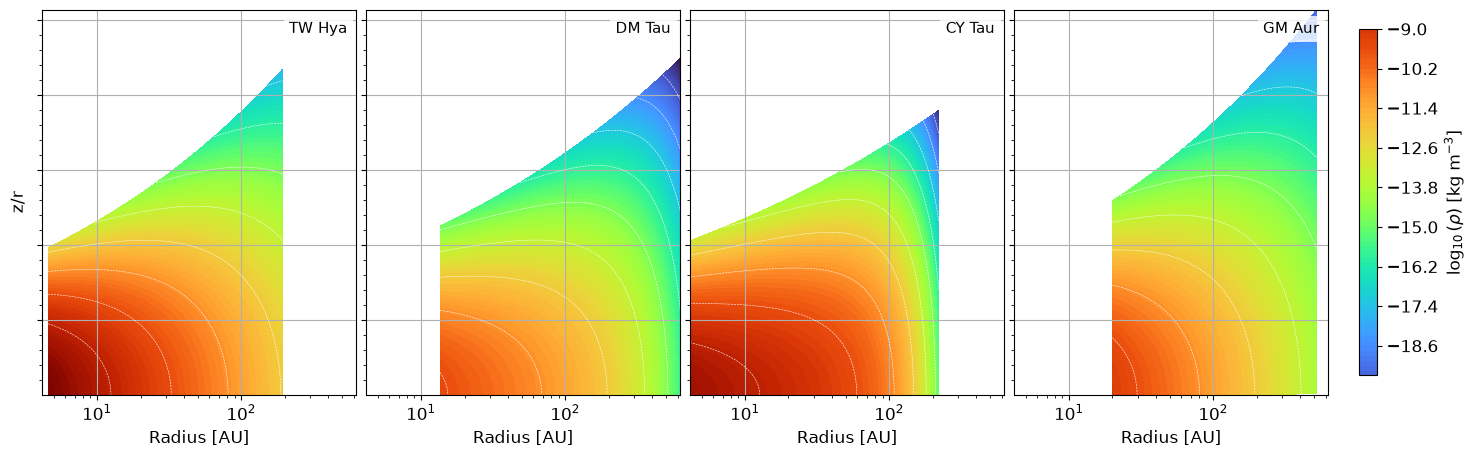

In [25]:
DMTau = {

'MSTAR':0.53,
'RSTAR':1.2262,
'LSTAR':0.232,
'TEFF':3779,

'RIN':13.5324,
'ROUT':628.12,
'RC':152.2485,
'GAMMA':0.588,

'MDISK':1.9462E-02,
'ALPHA':3e-3,

'T0':150,
'R0':1.0,
'Q':3-2*1.1799,

'NR':500,
'NZ':300

}

CYTau={

'MSTAR':0.43,
'RSTAR':1.5223,
'LSTAR':0.3595,
'TEFF':3636.7,

'RIN':4.1471,
'ROUT':220.,
'RC':58.3123,
'GAMMA':0.1071,

'MDISK':1.2042E-01,
'ALPHA':1e-3,

'T0':150,
'R0':1.0,
'Q':3-2*1.1541,

'NR':500,
'NZ':300

}

GMAur={

'MSTAR':0.70,
'RSTAR':1.6160,
'LSTAR':0.60,
'TEFF':4000,

'RIN':20.,
'ROUT':521.16,
'RC':100.,
'GAMMA':1.30,

'MDISK':3.3e-2,
'ALPHA':5e-3,

'T0':150,
'R0':1.0,
'Q':3-2*1.21,

'NR':500,
'NZ':300

}

TWHya=default_parameters().copy()

models=[]
for pars in [ TWHya, DMTau, CYTau, GMAur ]:
    d=DiskModel(pars)
    d.compute()
    models.append(d)

labels=[
'TW Hya',
'DM Tau',
'CY Tau',
'GM Aur'
]

plot_structure(models,labels)

# Build a joined inner/outer TW Hya disk model
Constructs a composite disk model from TW Hya inner and outer components and visualizes its density structure.


Joined disk shape: (999, 300)


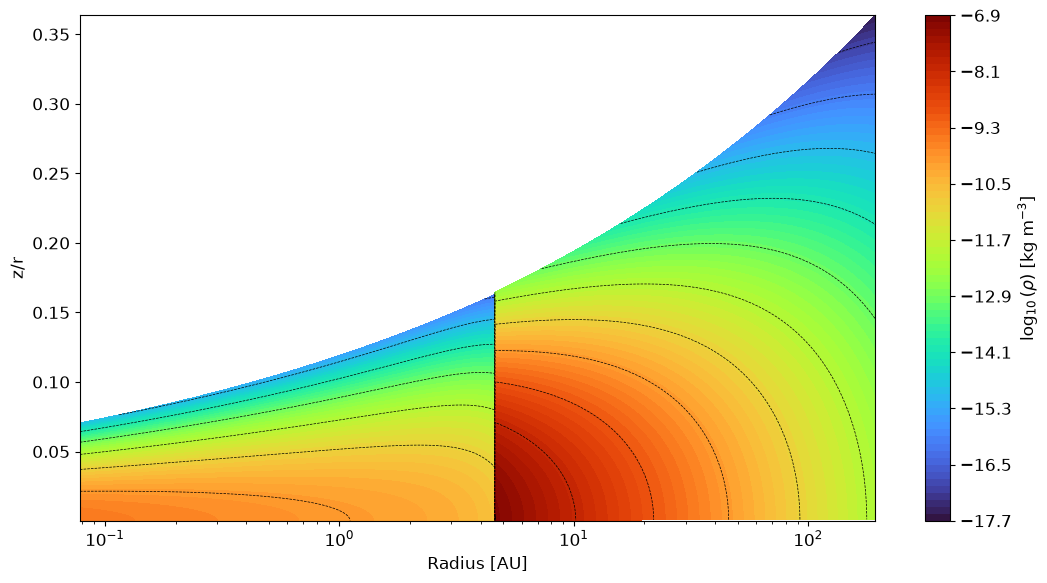

In [26]:
TWHya_inner_pars = {
    'MSTAR' : 0.75,
    'RSTAR' : 1.0888,
    'LSTAR' : 0.242,
    'TEFF'  : 4000.0,
    'RIN'   : 0.0781,
    'ROUT'  : 4.5784,
    'RC'    : 4.5784,
    'GAMMA' : -0.7788,
    'MDISK' : 1.0503e-6,
    'ALPHA' : 1e-3,
    'T0'    : 150.0,
    'R0'    : 1.0,
    'Q'     : (3 - 2*1.2052),
    'NR'    : 500,
    'NZ'    : 300
}

TWHya_outer_pars = {
    'MSTAR' : 0.75,
    'RSTAR' : 1.0888,
    'LSTAR' : 0.242,
    'TEFF'  : 4000.0,
    'RIN'   : 4.5784,
    'ROUT'  : 192.95,
    'RC'    : 48.0055,
    'GAMMA' : 1.5181,
    'MDISK' : 4.4769e-2,
    'ALPHA' : 1e-3,
    'T0'    : 150.0,
    'R0'    : 1.0,
    'Q'     : (3 - 2*1.2121),
    'NR'    : 500,
    'NZ'    : 300
}

DMTau_inner_pars={

'MSTAR':0.53,
'RSTAR':1.2262,
'LSTAR':0.232,
'TEFF':3779.0,

'RIN':0.9868,
'ROUT':13.5324,
'RC':13.5324,

'GAMMA':-0.9483,

'MDISK':1.1168e-6,
'ALPHA':3e-3,

'T0':150,
'R0':1,
'Q':(3-2*0.6621),

'NR':500,
'NZ':300

}


DMTau_outer_pars={

'MSTAR':0.53,
'RSTAR':1.2262,
'LSTAR':0.232,
'TEFF':3779.0,

'RIN':13.5324,
'ROUT':628.1200,
'RC':152.2485,

'GAMMA':0.5880,

'MDISK':1.9462e-2,
'ALPHA':3e-3,

'T0':150,
'R0':1,
'Q':(3-2*1.1799),

'NR':500,
'NZ':300

}

inner=DiskModel(TWHya_inner_pars)
inner.compute()

outer=DiskModel(TWHya_outer_pars)
outer.compute()


class JoinedDisk:
    pass


disk=JoinedDisk()


disk.R=np.concatenate((inner.R,outer.R[1:]))
disk.R_AU=np.concatenate((inner.R_AU,outer.R_AU[1:]))

disk.sigma=np.concatenate((inner.sigma,outer.sigma[1:]))

disk.T=np.concatenate((inner.T,outer.T[1:]))
disk.cs=np.concatenate((inner.cs,outer.cs[1:]))

disk.H=np.concatenate((inner.H,outer.H[1:]))
disk.H_AU=np.concatenate((inner.H_AU,outer.H_AU[1:]))

disk.aspect_ratio=np.concatenate((inner.aspect_ratio,
                                  outer.aspect_ratio[1:]))

disk.omega=np.concatenate((inner.omega,
                           outer.omega[1:]))

disk.vkep=np.concatenate((inner.vkep,
                          outer.vkep[1:]))

disk.rho=np.concatenate((inner.rho,
                         outer.rho[1:]),
                        axis=0)

disk.LOGRHO=np.log10(np.clip(disk.rho,1e-300,None))

disk.ZZ=np.concatenate((inner.ZZ,
                        outer.ZZ[1:]),
                       axis=0)

disk.ZZ_AU=np.concatenate((inner.ZZ_AU,
                           outer.ZZ_AU[1:]),
                          axis=0)

disk.RR=np.concatenate((inner.RR,
                        outer.RR[1:]),
                       axis=0)

disk.RR_AU=np.concatenate((inner.RR_AU,
                           outer.RR_AU[1:]),
                          axis=0)

disk.ZR=np.concatenate((inner.ZR,
                        outer.ZR[1:]),
                       axis=0)

disk.NR=len(disk.R)
disk.NZ=inner.NZ

mid=disk.NZ//2

disk.rho_mid=disk.rho[:,mid]

disk.Pmid=disk.rho_mid*disk.cs**2

disk.dPdr=np.gradient(disk.Pmid,disk.R)

disk.toomre_Q=np.concatenate((inner.toomre_Q,
                              outer.toomre_Q[1:]))

print("Joined disk shape:",disk.rho.shape)

DiskVisualizer.plot_density(disk)